# Examining Subgroup Performance

Notebook 5 measured how well the finalized models performed across the complete untouched test set. Notebook 6 explained what information those models used. This final notebook asks one more question:

> **Does the primary model perform consistently across different groups of participants?**

The analysis uses only the finalized gradient-boosting model and its frozen **0.130** screening threshold. It examines four separately defined dimensions:

1. **Age group**
2. **Sex**
3. **Race/ethnicity**
4. **Income-to-poverty-ratio group**

The groups are never combined. A race-by-sex analysis, for example, would divide the 2,643-person test set into small cells with unstable estimates. The goal is a focused reliability check rather than an exhaustive search for differences.

Nothing in this notebook retrains the model, changes its features, or selects a new threshold.


## What Subgroup Analysis Can and Cannot Tell Us

Subgroup analysis checks whether a strong overall result hides a weaker result for a particular set of participants. That matters for a screening model because an overall recall of 80% does not guarantee 80% recall inside every group.

Several limits are important:

- **A difference is not automatically unfairness.** It may reflect sample size, cavity prevalence, measurement, access to care, or information missing from the questionnaire.
- **Ranking and threshold behavior are different.** ROC-AUC and PR-AUC describe how well probabilities rank participants. Recall, specificity, and the share flagged also depend on where the fixed 0.130 threshold falls inside a group's score distribution.
- **PR-AUC depends on prevalence.** A group with more cavities has a higher no-skill PR-AUC, so PR-AUC must be read beside that group's prevalence.
- **A small average calibration gap is not complete calibration.** Matching a group's mean risk does not prove that individual probabilities or their spread are correct.
- **Confidence intervals describe uncertainty.** Overlapping intervals do not prove that two groups are equal. The notebook calculates paired differences between each group and everyone outside that group.
- **Race and ethnicity are not biological mechanisms.** Differences may reflect social conditions, access, exposures, and how the model uses the available predictors.
- **This is exploratory.** Many subgroup metrics are displayed without a multiple-comparison correction, so the results identify validation priorities rather than final clinical conclusions.


## Intended Use and Survey Design

The intended use remains **questionnaire-based screening and referral prioritization before a dental examination**. The model does not diagnose cavities and a low prediction cannot rule one out.

NHANES survey weights, strata, and primary sampling units are not incorporated because this project studies individual-level prediction rather than national population estimation. The confidence intervals below use an ordinary participant-level bootstrap. They describe uncertainty in this analytic test set, not survey-design-based national uncertainty.


## Imports and Setup


In [74]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.special import logit

try:
    from IPython.display import Markdown, display
except ImportError:
    # Jupyter normally provides these functions. The fallback keeps
    # the notebook readable if the cells are run as ordinary Python.
    def display(value):
        print(value)

    def Markdown(value):
        return value

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score


# Find the project folder whether VS Code starts Jupyter from the
# repository root or from inside the notebooks folder.
current_folder = Path.cwd().resolve()
for candidate in [current_folder, current_folder.parent]:
    if (candidate / "data" / "processed" / "test_data.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find data/processed/test_data.csv. Open this "
        "notebook from inside the project repository."
    )

TRAINING_PATH = PROJECT_ROOT / "data" / "processed" / "training_data.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test_data.csv"
MODEL_FOLDER = PROJECT_ROOT / "outputs" / "models"
TABLE_FOLDER = PROJECT_ROOT / "outputs" / "tables"

TRAINING_METADATA_PATH = MODEL_FOLDER / "model_metadata.json"
EVALUATION_METADATA_PATH = MODEL_FOLDER / "test_evaluation_metadata.json"
INTERPRETATION_METADATA_PATH = (
    MODEL_FOLDER / "model_interpretation_metadata.json"
)
PRIMARY_MODEL_PATH = MODEL_FOLDER / "gradient_boosting.joblib"
TEST_RESULTS_PATH = TABLE_FOLDER / "model_test_results.csv"
TEST_PREDICTIONS_PATH = TABLE_FOLDER / "model_test_predictions.csv"
OOF_PREDICTIONS_PATH = (
    TABLE_FOLDER / "model_out_of_fold_predictions.csv"
)

RANDOM_STATE = 42
N_BOOTSTRAPS = 2_000

ORANGE = "#f59e0b"
BLUE = "#2f80ed"
PURPLE = "#5d32ca"
GREEN = "#82b600"
RED = "#d64545"
GRAY = "#8a8a8a"

DIMENSION_COLORS = {
    "Age group": ORANGE,
    "Sex": BLUE,
    "Race/ethnicity": PURPLE,
    "Income group": GREEN,
}

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print(f"Project folder: {PROJECT_ROOT.name}")
print(f"Bootstrap resamples: {N_BOOTSTRAPS:,}")


Project folder: Dental Caries Prediction Project
Bootstrap resamples: 2,000


## Loading and Verifying the Finalized Project


In [75]:
required_artifacts = [
    TRAINING_PATH,
    TEST_PATH,
    TRAINING_METADATA_PATH,
    EVALUATION_METADATA_PATH,
    INTERPRETATION_METADATA_PATH,
    PRIMARY_MODEL_PATH,
    TEST_RESULTS_PATH,
    TEST_PREDICTIONS_PATH,
    OOF_PREDICTIONS_PATH,
]

missing_artifacts = [
    str(path.relative_to(PROJECT_ROOT))
    for path in required_artifacts
    if not path.exists()
]
assert not missing_artifacts, (
    "Required finalized artifacts are missing: "
    + ", ".join(missing_artifacts)
)

with open(TRAINING_METADATA_PATH) as file:
    training_metadata = json.load(file)
with open(EVALUATION_METADATA_PATH) as file:
    evaluation_metadata = json.load(file)
with open(INTERPRETATION_METADATA_PATH) as file:
    interpretation_metadata = json.load(file)

primary_model_name = training_metadata["primary_model"]
primary_threshold = float(training_metadata["primary_threshold"])
feature_columns = training_metadata["features"]

# The same model and threshold must remain finalized across all three
# metadata files before subgroup outcomes are examined.
assert primary_model_name == "Gradient Boosting"
assert evaluation_metadata["primary_model"] == primary_model_name
assert interpretation_metadata["primary_model"] == primary_model_name
assert np.isclose(
    evaluation_metadata["frozen_thresholds"][primary_model_name],
    primary_threshold,
)
assert np.isclose(
    interpretation_metadata["primary_threshold"],
    primary_threshold,
)

current_test_hash = hashlib.sha256(TEST_PATH.read_bytes()).hexdigest()
current_model_hash = hashlib.sha256(
    PRIMARY_MODEL_PATH.read_bytes()
).hexdigest()

assert current_test_hash == evaluation_metadata["test_file_sha256"]
assert current_test_hash == interpretation_metadata["test_file_sha256"]
assert current_model_hash == evaluation_metadata["model_sha256"][
    primary_model_name
]
assert current_model_hash == interpretation_metadata[
    "primary_model_sha256"
]

print(f"Primary model: {primary_model_name}")
print(f"Frozen threshold: {primary_threshold:.3f}")
print("Data, model, and metadata fingerprints verified.")


Primary model: Gradient Boosting
Frozen threshold: 0.130
Data, model, and metadata fingerprints verified.


## Reproducing the Final Test Predictions


In [76]:
training_data = pd.read_csv(TRAINING_PATH)
test_data = pd.read_csv(TEST_PATH)
saved_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)
out_of_fold_predictions = pd.read_csv(OOF_PREDICTIONS_PATH)
primary_pipeline = joblib.load(PRIMARY_MODEL_PATH)
saved_test_results = pd.read_csv(TEST_RESULTS_PATH).set_index("Model")

current_training_hash = hashlib.sha256(
    TRAINING_PATH.read_bytes()
).hexdigest()
assert current_training_hash == training_metadata["training_file_sha256"]
assert len(training_data) == training_metadata["training_rows"]
assert len(test_data) == evaluation_metadata["test_rows"]
assert test_data["SEQN"].is_unique
assert saved_predictions["SEQN"].is_unique
assert out_of_fold_predictions["SEQN"].is_unique
assert len(out_of_fold_predictions) == len(training_data)
assert set(feature_columns).issubset(test_data.columns)

X_test = test_data[feature_columns]
y_test = test_data["has_cavity"].astype(int).to_numpy()

fresh_probabilities = primary_pipeline.predict_proba(X_test)[:, 1]
fresh_predictions = (
    fresh_probabilities >= primary_threshold
).astype(int)

prediction_check = test_data[["SEQN", "has_cavity"]].merge(
    saved_predictions[
        [
            "SEQN",
            "has_cavity",
            "gradient_boosting_probability",
            "gradient_boosting_prediction",
        ]
    ],
    on="SEQN",
    suffixes=("_test", "_saved"),
    validate="one_to_one",
)

assert len(prediction_check) == len(test_data)
assert np.array_equal(
    prediction_check["has_cavity_test"],
    prediction_check["has_cavity_saved"],
)
np.testing.assert_allclose(
    fresh_probabilities,
    prediction_check["gradient_boosting_probability"],
    rtol=1e-12,
    atol=1e-12,
)
assert np.array_equal(
    fresh_predictions,
    prediction_check["gradient_boosting_prediction"],
)

print(f"Participants: {len(test_data):,}")
print(f"Cavity cases: {y_test.sum():,}")
print("Fresh predictions exactly reproduce Notebook 5.")


Participants: 2,643
Cavity cases: 484
Fresh predictions exactly reproduce Notebook 5.


## Defining the Four Subgroup Dimensions


In [77]:
analysis_data = test_data[["SEQN", "has_cavity"]].copy()
analysis_data["Probability"] = fresh_probabilities
analysis_data["Prediction"] = fresh_predictions

# These are the same age bands used for the SHAP summary in Notebook 6.
age_order = ["1–11", "12–17", "18–34", "35–49", "50–64", "65+"]
analysis_data["Age group"] = pd.cut(
    test_data["age"],
    bins=[0, 12, 18, 35, 50, 65, np.inf],
    labels=age_order,
    right=False,
)

sex_order = ["Female", "Male"]
analysis_data["Sex"] = pd.Categorical(
    np.where(test_data["sex_female"].eq(1), "Female", "Male"),
    categories=sex_order,
    ordered=True,
)

race_columns = {
    "race_mexican_american": "Mexican American",
    "race_other_hispanic": "Other Hispanic",
    "race_non-hispanic_black": "Non-Hispanic Black",
    "race_non-hispanic_asian": "Non-Hispanic Asian",
    "race_other_multi": "Other or multiracial",
}
assert test_data[list(race_columns)].sum(axis=1).le(1).all()

race_order = [
    "Mexican American",
    "Other Hispanic",
    "Non-Hispanic White",
    "Non-Hispanic Black",
    "Non-Hispanic Asian",
    "Other or multiracial",
]
race_labels = np.full(
    len(test_data),
    "Non-Hispanic White",
    dtype=object,
)
for column, label in race_columns.items():
    race_labels[test_data[column].eq(1).to_numpy()] = label
analysis_data["Race/ethnicity"] = pd.Categorical(
    race_labels,
    categories=race_order,
    ordered=True,
)

# Missing income remains its own transparent group. It is not assigned
# to the median-income band used internally by the prediction pipeline.
income_order = [
    "Below poverty (<1.00)",
    "Near poverty (1.00–1.99)",
    "Middle income (2.00–3.99)",
    "Higher income (4.00+)",
    "Income not reported",
]
income_labels = np.full(len(test_data), "", dtype=object)
income_missing = test_data["income_poverty_ratio_missing"].eq(1)
observed_income = ~income_missing

income_labels[income_missing.to_numpy()] = "Income not reported"
income_labels[
    (observed_income & test_data["income_poverty_ratio"].lt(1)).to_numpy()
] = "Below poverty (<1.00)"
income_labels[
    (
        observed_income
        & test_data["income_poverty_ratio"].ge(1)
        & test_data["income_poverty_ratio"].lt(2)
    ).to_numpy()
] = "Near poverty (1.00–1.99)"
income_labels[
    (
        observed_income
        & test_data["income_poverty_ratio"].ge(2)
        & test_data["income_poverty_ratio"].lt(4)
    ).to_numpy()
] = "Middle income (2.00–3.99)"
income_labels[
    (observed_income & test_data["income_poverty_ratio"].ge(4)).to_numpy()
] = "Higher income (4.00+)"

assert (income_labels != "").all()
analysis_data["Income group"] = pd.Categorical(
    income_labels,
    categories=income_order,
    ordered=True,
)

group_order = {
    "Age group": age_order,
    "Sex": sex_order,
    "Race/ethnicity": race_order,
    "Income group": income_order,
}

for dimension in group_order:
    assert analysis_data[dimension].notna().all()
assert (
    analysis_data["Income group"].eq("Income not reported").sum()
    == income_missing.sum()
)

group_definitions = pd.DataFrame(
    [
        {
            "Dimension": "Age group",
            "Definition": "Same six age bands used in Notebook 6",
        },
        {
            "Dimension": "Sex",
            "Definition": "Female and male categories available in NHANES",
        },
        {
            "Dimension": "Race/ethnicity",
            "Definition": "Six mutually exclusive NHANES categories",
        },
        {
            "Dimension": "Income group",
            "Definition": (
                "Family income-to-poverty ratio; missing reports remain "
                "a separate data-availability group"
            ),
        },
    ]
)
group_definitions


,Dimension,Definition
0,Age group,Same six age bands used in Notebook 6
1,Sex,Female and male categories available in NHANES
2,Race/ethnicity,Six mutually exclusive NHANES categories
3,Income group,Family income-to-poverty ratio; missing reports remain a separate data-availability group


The income-to-poverty ratio compares family income with the federal poverty threshold for that household. A value below 1.00 indicates income below the threshold. The highest NHANES value is top-coded, so the last observed category is written as 4.00+ rather than interpreted as an exact income amount.

**Income not reported** is included so those participants remain visible. It is a data-availability group—not a fifth income level—and its results should not be ordered beside the observed-income categories.

The same distinction is preserved in the paired comparisons. Each reported-income group is compared only with participants in the other **reported** income groups; participants with unreported income are excluded from that complement. The missing-income group itself is compared with everyone whose income was reported.


## Calculating the Subgroup Metrics


In [78]:
def safe_divide(numerator, denominator):
    # Protect against an empty denominator in a future subgroup.
    return numerator / denominator if denominator else np.nan


def calculate_metrics(frame):
    # Calculate ranking, threshold, and calibration metrics together.
    #
    # Confusion-matrix counts and the Brier score are computed directly
    # instead of through sklearn's confusion_matrix/brier_score_loss.
    # This cell calls calculate_metrics roughly 76,000 times during the
    # bootstrap below, and sklearn's per-call input validation dominates
    # that runtime even though labels and predictions are already clean
    # 0/1 arrays here. PR-AUC and ROC-AUC stay on sklearn: their tie
    # handling is not a simple sum to hand-rolled, and both were verified
    # against the bootstrap data to match sklearn's numbers exactly
    # (confusion-matrix counts and Brier score match to floating-point
    # precision, about 1e-16).
    labels = frame["has_cavity"].to_numpy(dtype=int)
    probabilities = frame["Probability"].to_numpy(dtype=float)
    predictions = frame["Prediction"].to_numpy(dtype=int)

    negative_count = int((labels == 0).sum())
    positive_count = int((labels == 1).sum())

    if negative_count and positive_count:
        pr_auc = average_precision_score(labels, probabilities)
        roc_auc = roc_auc_score(labels, probabilities)
    else:
        pr_auc = np.nan
        roc_auc = np.nan

    true_positive = int(((predictions == 1) & (labels == 1)).sum())
    false_positive = int(((predictions == 1) & (labels == 0)).sum())
    false_negative = int(((predictions == 0) & (labels == 1)).sum())
    true_negative = int(((predictions == 0) & (labels == 0)).sum())

    prevalence = labels.mean()
    mean_probability = probabilities.mean()
    brier_score = np.mean((probabilities - labels) ** 2)
    prevalence_only_brier = prevalence * (1 - prevalence)

    return {
        "Participants": len(frame),
        "Cavity cases": positive_count,
        "Prevalence": prevalence,
        "PR-AUC": pr_auc,
        "PR-AUC skill": (
            (pr_auc - prevalence) / (1 - prevalence)
            if prevalence < 1
            else np.nan
        ),
        "ROC-AUC": roc_auc,
        "Recall": safe_divide(
            true_positive,
            true_positive + false_negative,
        ),
        "Specificity": safe_divide(
            true_negative,
            true_negative + false_positive,
        ),
        "Precision": safe_divide(
            true_positive,
            true_positive + false_positive,
        ),
        "NPV": safe_divide(
            true_negative,
            true_negative + false_negative,
        ),
        "False-negative rate": safe_divide(
            false_negative,
            true_positive + false_negative,
        ),
        "False-positive rate": safe_divide(
            false_positive,
            true_negative + false_positive,
        ),
        "Share flagged": predictions.mean(),
        "Brier score": brier_score,
        "Brier skill": (
            1 - brier_score / prevalence_only_brier
            if prevalence_only_brier > 0
            else np.nan
        ),
        "Mean predicted probability": mean_probability,
        "Calibration gap": mean_probability - prevalence,
        "True negatives": int(true_negative),
        "False positives": int(false_positive),
        "False negatives": int(false_negative),
        "True positives": int(true_positive),
    }


overall_metrics = calculate_metrics(analysis_data)
point_rows = []

for dimension, ordered_groups in group_order.items():
    for group_name in ordered_groups:
        group_data = analysis_data.loc[
            analysis_data[dimension].eq(group_name)
        ]
        group_metrics = calculate_metrics(group_data)
        point_rows.append(
            {
                "Dimension": dimension,
                "Group": group_name,
                **group_metrics,
            }
        )

subgroup_point_results = pd.DataFrame(point_rows)

# Reproduce Notebook 5 before making any subgroup comparison.
notebook5_primary = saved_test_results.loc[primary_model_name]
for metric_name in [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Specificity",
    "Precision",
    "Brier score",
]:
    np.testing.assert_allclose(
        overall_metrics[metric_name],
        notebook5_primary[metric_name],
        rtol=1e-12,
        atol=1e-12,
    )

assert subgroup_point_results["Participants"].gt(0).all()
assert subgroup_point_results["Cavity cases"].gt(0).all()

print(
    "Overall test result reproduced: "
    f"PR-AUC {overall_metrics['PR-AUC']:.3f}, "
    f"recall {overall_metrics['Recall']:.3f}."
)
subgroup_point_results[
    [
        "Dimension",
        "Group",
        "Participants",
        "Cavity cases",
        "Prevalence",
        "PR-AUC",
        "PR-AUC skill",
        "ROC-AUC",
        "Recall",
        "Specificity",
        "Precision",
    ]
].round(3)


Overall test result reproduced: PR-AUC 0.449, recall 0.818.


,Dimension,Group,Participants,Cavity cases,Prevalence,PR-AUC,PR-AUC skill,ROC-AUC,Recall,Specificity,Precision
0,Age group,1–11,658,88,0.134,0.314,0.208,0.776,0.716,0.649,0.240
1,Age group,12–17,294,30,0.102,0.301,0.221,0.693,0.633,0.689,0.188
2,Age group,18–34,474,111,0.234,0.513,0.364,0.740,0.865,0.399,0.306
3,Age group,35–49,369,99,0.268,0.550,0.386,0.791,0.919,0.389,0.355
4,Age group,50–64,449,103,0.229,0.452,0.289,0.733,0.816,0.480,0.318
5,Age group,65+,399,53,0.133,0.379,0.284,0.817,0.811,0.662,0.269
6,Sex,Female,1342,230,0.171,0.439,0.323,0.787,0.809,0.592,0.291
7,Sex,Male,1301,254,0.195,0.462,0.331,0.766,0.827,0.515,0.292
8,Race/ethnicity,Mexican American,349,56,0.160,0.337,0.211,0.712,0.768,0.509,0.230
9,Race/ethnicity,Other Hispanic,238,39,0.164,0.308,0.172,0.689,0.718,0.518,0.226


## Adding Bootstrap Confidence Intervals


The model is not retrained during the bootstrap. Each resample draws 2,643 participants from the finalized test set with replacement, then recalculates every subgroup metric from the already-frozen predictions.

The **same resampled participant indices** are reused across every subgroup. For direct comparisons, each group is paired with its **complement**, everyone in that dimension who is not in the group. This is cleaner than comparing with the overall test result because the overall result contains members of the subgroup and pulls the difference toward zero.

There is one deliberate exception for income. The complement of a reported-income group contains only the other reported-income groups, not the separate **Income not reported** category. This makes each observed-income comparison interpretable. The missing-income category is still evaluated and is compared with all participants whose income was reported.

Because sampling starts from the complete test set, subgroup sizes vary slightly across resamples. The intervals therefore represent what might happen in another sample drawn from the same analytic population rather than holding every subgroup count fixed by design.

Percentile intervals use 2,000 resamples and the same random seed as Notebook 5. They measure participant-sampling uncertainty only; they do not incorporate NHANES survey design, model-development uncertainty, or correction for the many displayed comparisons.


> **Runtime note:** this cell recomputes 15 metrics for 19 groups and their complements, inside each of 2,000 resamples which is about 76,000 metric calculations. On this project's development machine it took roughly 3 minutes; expect a similar order of magnitude here. It has no progress output while running, so it is not stuck if the kernel just looks busy.

In [79]:
bootstrap_metrics = [
    "Prevalence",
    "PR-AUC",
    "PR-AUC skill",
    "ROC-AUC",
    "Recall",
    "Specificity",
    "Precision",
    "NPV",
    "False-negative rate",
    "False-positive rate",
    "Share flagged",
    "Brier score",
    "Brier skill",
    "Mean predicted probability",
    "Calibration gap",
]

difference_metrics = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Specificity",
    "Precision",
    "False-positive rate",
    "Calibration gap",
]

def get_complement_mask(frame, dimension, group_name):
    # Income not reported is a missingness category, not an income level.
    # Keep it out of the complement for every reported-income contrast.
    outside_group = frame[dimension].ne(group_name)
    if dimension == "Income group" and group_name != "Income not reported":
        outside_group &= frame[dimension].ne("Income not reported")
    return outside_group


rng = np.random.default_rng(RANDOM_STATE)
bootstrap_rows = []

for iteration in range(N_BOOTSTRAPS):
    sampled_indices = rng.integers(
        0,
        len(analysis_data),
        size=len(analysis_data),
    )
    sampled_data = analysis_data.iloc[sampled_indices]

    for dimension, ordered_groups in group_order.items():
        for group_name in ordered_groups:
            group_mask = sampled_data[dimension].eq(group_name)
            sampled_group = sampled_data.loc[group_mask]
            complement_mask = get_complement_mask(
                sampled_data,
                dimension,
                group_name,
            )
            sampled_complement = sampled_data.loc[complement_mask]

            group_metrics = calculate_metrics(sampled_group)
            complement_metrics = calculate_metrics(sampled_complement)

            row = {
                "Bootstrap iteration": iteration,
                "Dimension": dimension,
                "Group": group_name,
                **{
                    metric: group_metrics[metric]
                    for metric in bootstrap_metrics
                },
            }
            row.update(
                {
                    f"Complement {metric}": complement_metrics[metric]
                    for metric in difference_metrics
                }
            )
            bootstrap_rows.append(row)

bootstrap_distributions = pd.DataFrame(bootstrap_rows)

interval_rows = []
difference_rows = []

for point_row in subgroup_point_results.to_dict("records"):
    dimension = point_row["Dimension"]
    group_name = point_row["Group"]
    group_bootstrap = bootstrap_distributions.loc[
        bootstrap_distributions["Dimension"].eq(dimension)
        & bootstrap_distributions["Group"].eq(group_name)
    ].set_index("Bootstrap iteration")

    point_complement_mask = get_complement_mask(
        analysis_data,
        dimension,
        group_name,
    )
    complement_point = calculate_metrics(
        analysis_data.loc[point_complement_mask]
    )

    for metric in bootstrap_metrics:
        valid_values = group_bootstrap[metric].dropna()
        lower, upper = valid_values.quantile([0.025, 0.975])
        interval_rows.append(
            {
                "Dimension": dimension,
                "Group": group_name,
                "Metric": metric,
                "Estimate": point_row[metric],
                "Lower 95%": lower,
                "Upper 95%": upper,
                "Valid resamples": len(valid_values),
            }
        )

    for metric in difference_metrics:
        differences = (
            group_bootstrap[metric]
            - group_bootstrap[f"Complement {metric}"]
        ).dropna()
        lower, upper = differences.quantile([0.025, 0.975])
        observed_difference = (
            point_row[metric] - complement_point[metric]
        )
        difference_rows.append(
            {
                "Dimension": dimension,
                "Group": group_name,
                "Metric": metric,
                "Difference from complement": observed_difference,
                "Lower 95%": lower,
                "Upper 95%": upper,
                "Interval excludes zero": bool(lower > 0 or upper < 0),
                "Valid resamples": len(differences),
            }
        )

subgroup_intervals = pd.DataFrame(interval_rows)
subgroup_differences = pd.DataFrame(difference_rows)

# AUC is undefined only if a bootstrap subgroup contains one class. Every
# displayed metric should therefore retain nearly all 2,000 resamples.
assert subgroup_intervals["Valid resamples"].min() >= 1_950
assert subgroup_differences["Valid resamples"].min() >= 1_950

# Confirm that unreported income cannot silently enter an observed-income
# reference group after any future edit to the labels.
for income_group in group_order["Income group"][:-1]:
    income_complement = analysis_data.loc[
        get_complement_mask(
            analysis_data,
            "Income group",
            income_group,
        )
    ]
    assert not income_complement["Income group"].eq(
        "Income not reported"
    ).any()

print(
    f"Calculated {len(subgroup_intervals):,} confidence intervals "
    f"and group-versus-complement differences from "
    f"{N_BOOTSTRAPS:,} paired bootstrap resamples."
)


Calculated 285 confidence intervals and group-versus-complement differences from 2,000 paired bootstrap resamples.


In [80]:
def interval_lookup(metric):
    # Return one ordered interval table for plotting or display.
    metric_data = subgroup_intervals.loc[
        subgroup_intervals["Metric"].eq(metric)
    ].copy()
    order_lookup = {
        (dimension, group): index
        for dimension, groups in group_order.items()
        for index, group in enumerate(groups)
    }
    metric_data["Order"] = [
        order_lookup[(dimension, group)]
        for dimension, group in zip(
            metric_data["Dimension"],
            metric_data["Group"],
        )
    ]
    return metric_data.sort_values(["Dimension", "Order"])


def display_interval(estimate, lower, upper):
    # Format one point estimate and its percentile interval.
    return f"{estimate:.3f} ({lower:.3f}–{upper:.3f})"


def plot_single_metric(
    metric, title, reference=None, reference_label="Overall test set",
    xlim=(0, 1),
):
    # Draw the same metric across all four subgroup dimensions.
    figure, axes = plt.subplots(2, 2, figsize=(15, 11))
    metric_data = interval_lookup(metric)

    for axis, (dimension, ordered_groups) in zip(
        axes.flat,
        group_order.items(),
    ):
        panel = (
            metric_data.loc[
                metric_data["Dimension"].eq(dimension)
            ]
            .set_index("Group")
            .loc[ordered_groups]
            .reset_index()
        )
        y_positions = np.arange(len(panel))
        lower_error = panel["Estimate"] - panel["Lower 95%"]
        upper_error = panel["Upper 95%"] - panel["Estimate"]

        axis.errorbar(
            panel["Estimate"],
            y_positions,
            xerr=np.vstack([lower_error, upper_error]),
            fmt="o",
            color=DIMENSION_COLORS[dimension],
            ecolor=DIMENSION_COLORS[dimension],
            capsize=3,
            markersize=6,
        )
        if reference is not None:
            # Labeled so the dashed line reads as a number, not a mark
            # with no explanation, in every panel it appears in.
            axis.axvline(
                reference,
                color=GRAY,
                linestyle="--",
                linewidth=1.5,
                label=f"{reference_label}: {reference:.3f}",
            )
            axis.legend(loc="lower right", fontsize=8, framealpha=0.9)
        axis.set_yticks(y_positions)
        axis.set_yticklabels(panel["Group"])
        axis.invert_yaxis()
        axis.set_xlim(*xlim)
        axis.set_xlabel(metric)
        axis.set_title(dimension)

    figure.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


## Who Is Represented in the Test Set?


In [81]:
prevalence_intervals = interval_lookup("Prevalence")
composition_table = subgroup_point_results[
    [
        "Dimension",
        "Group",
        "Participants",
        "Cavity cases",
        "Prevalence",
    ]
].merge(
    prevalence_intervals[
        ["Dimension", "Group", "Lower 95%", "Upper 95%"]
    ],
    on=["Dimension", "Group"],
    how="left",
    validate="one_to_one",
)
composition_table["Prevalence (95% CI)"] = [
    display_interval(estimate, lower, upper)
    for estimate, lower, upper in zip(
        composition_table["Prevalence"],
        composition_table["Lower 95%"],
        composition_table["Upper 95%"],
    )
]

# The whole test set, shown once as the reference every group below is
# implicitly compared against. It has no interval here because it was
# not resampled as its own bootstrap group in the cell above; only the
# subgroups and their complements were.
overall_reference_row = pd.DataFrame(
    [
        {
            "Dimension": "Overall",
            "Group": "All participants (test set)",
            "Participants": len(analysis_data),
            "Cavity cases": int(analysis_data["has_cavity"].sum()),
            "Prevalence (95% CI)": (
                f"{overall_metrics['Prevalence']:.3f} (reference)"
            ),
        }
    ]
)

pd.concat(
    [
        overall_reference_row,
        composition_table[
            [
                "Dimension",
                "Group",
                "Participants",
                "Cavity cases",
                "Prevalence (95% CI)",
            ]
        ],
    ],
    ignore_index=True,
)


,Dimension,Group,Participants,Cavity cases,Prevalence (95% CI)
0,Overall,All participants (test set),2643,484,0.183 (reference)
1,Age group,1–11,658,88,0.134 (0.108–0.161)
2,Age group,12–17,294,30,0.102 (0.068–0.138)
3,Age group,18–34,474,111,0.234 (0.196–0.272)
4,Age group,35–49,369,99,0.268 (0.224–0.314)
5,Age group,50–64,449,103,0.229 (0.192–0.270)
6,Age group,65+,399,53,0.133 (0.102–0.166)
7,Sex,Female,1342,230,0.171 (0.150–0.191)
8,Sex,Male,1301,254,0.195 (0.174–0.217)
9,Race/ethnicity,Mexican American,349,56,0.160 (0.122–0.200)


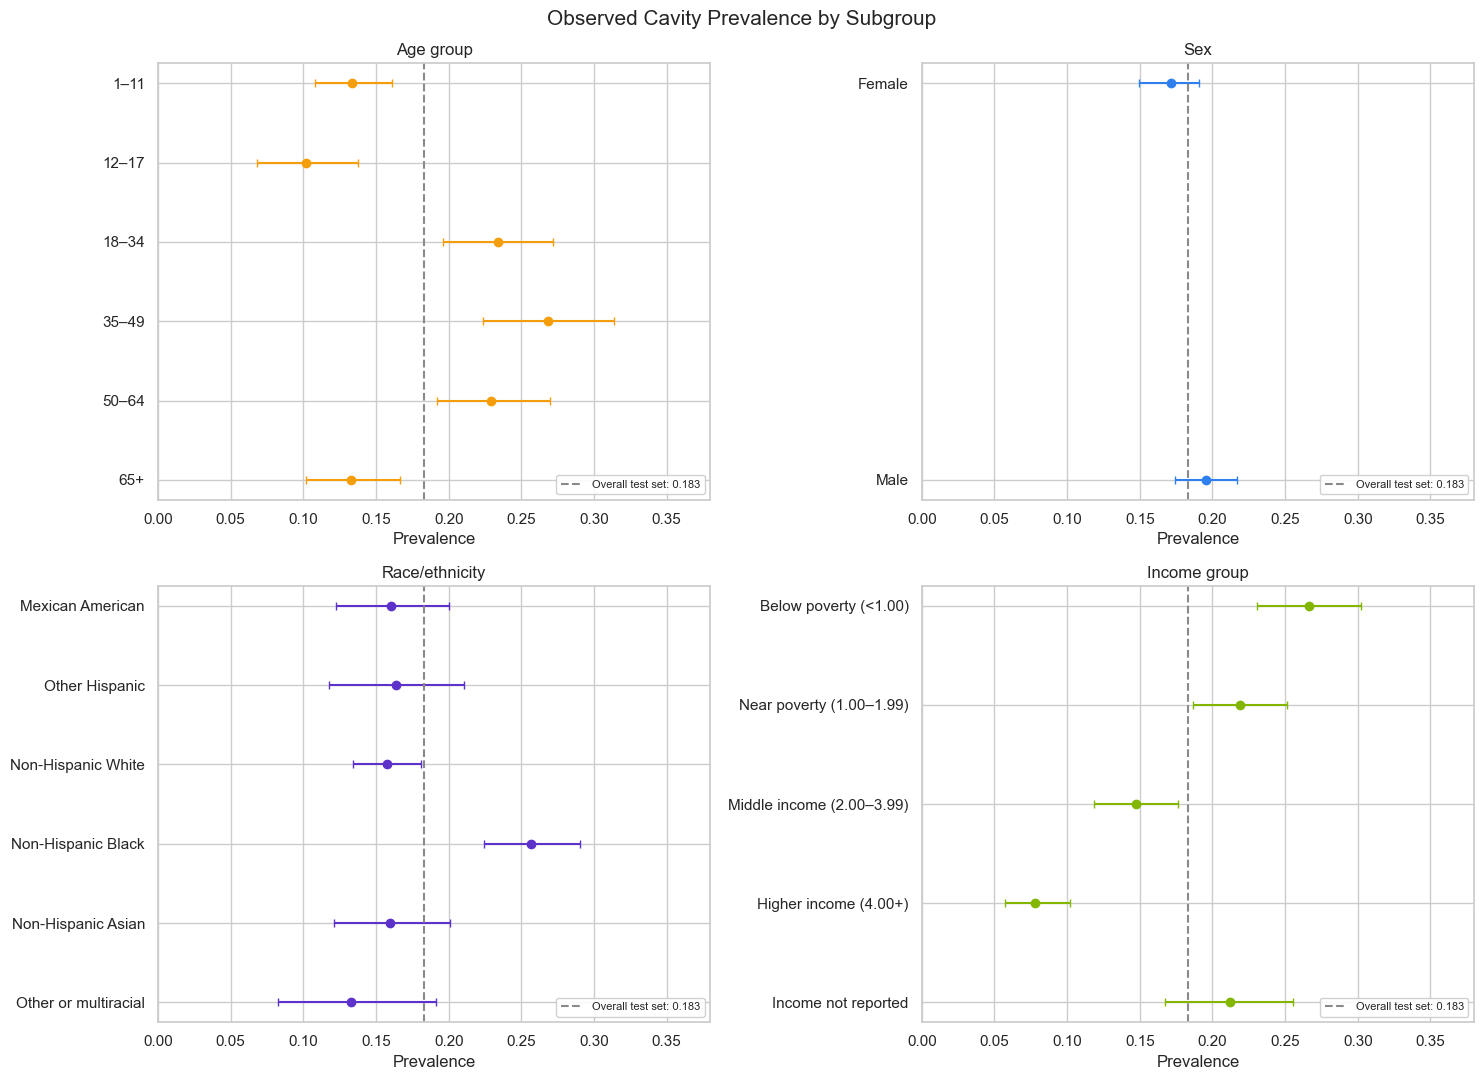

In [82]:
plot_single_metric(
    metric="Prevalence",
    title="Observed Cavity Prevalence by Subgroup",
    reference=overall_metrics["Prevalence"],
    xlim=(0, 0.38),
)


In [83]:
prevalence_ranked = subgroup_point_results.sort_values("Prevalence")
lowest_prevalence = prevalence_ranked.iloc[0]
highest_prevalence = prevalence_ranked.iloc[-1]
smallest_group = subgroup_point_results.nsmallest(1, "Participants").iloc[0]

display(
    Markdown(
        f"Across the displayed groups, observed cavity prevalence ranges "
        f"from **{lowest_prevalence['Prevalence']:.1%}** in "
        f"**{lowest_prevalence['Group']}** to "
        f"**{highest_prevalence['Prevalence']:.1%}** in "
        f"**{highest_prevalence['Group']}**. The smallest displayed "
        f"group is **{smallest_group['Group']}** with "
        f"{int(smallest_group['Participants']):,} participants and "
        f"{int(smallest_group['Cavity cases']):,} cavity cases. Its "
        "intervals should therefore be read more cautiously than those "
        "from larger groups."
    )
)


Across the displayed groups, observed cavity prevalence ranges from **7.8%** in **Higher income (4.00+)** to **26.8%** in **35–49**. The smallest displayed group is **Other or multiracial** with 166 participants and 22 cavity cases. Its intervals should therefore be read more cautiously than those from larger groups.

## Discrimination Within Each Group


**Discrimination** asks whether the model gives higher probabilities to participants with cavities than to participants without them.

- **PR-AUC** is the primary metric because cavities are the minority outcome. Its no-skill reference equals the prevalence inside that group.
- **ROC-AUC** is less directly tied to prevalence and provides a useful second view, although it does not describe the screening threshold.
- **PR-AUC skill** is `(PR-AUC − prevalence) / (1 − prevalence)`. A value of 0 means the model does no better than that group's prevalence-only reference, while 1 would be perfect. Normalizing the gain makes comparisons fairer when subgroup prevalence differs.

Age and income require an additional caution because they are also model predictors. Stratifying by age removes the between-age variation that helps the pooled model rank participants, so a within-age ROC-AUC should not be expected to reproduce the pooled ROC-AUC. Income has the same issue more weakly. Sex and race/ethnicity contribute less predictive signal, so their within-group discrimination differences are less explained by this restriction-of-range effect.


In [84]:
discrimination_metrics = [
    "Prevalence",
    "PR-AUC",
    "PR-AUC skill",
    "ROC-AUC",
]
discrimination_table = subgroup_point_results[
    ["Dimension", "Group", "Participants", "Cavity cases"]
    + discrimination_metrics
].copy()

for metric in ["PR-AUC", "ROC-AUC"]:
    metric_intervals = interval_lookup(metric)[
        [
            "Dimension",
            "Group",
            "Estimate",
            "Lower 95%",
            "Upper 95%",
        ]
    ].rename(
        columns={
            "Estimate": f"{metric} estimate",
            "Lower 95%": f"{metric} lower 95%",
            "Upper 95%": f"{metric} upper 95%",
        }
    )
    discrimination_table = discrimination_table.merge(
        metric_intervals,
        on=["Dimension", "Group"],
        how="left",
        validate="one_to_one",
    )

discrimination_table.round(3)


,Dimension,Group,Participants,Cavity cases,Prevalence,PR-AUC,PR-AUC skill,ROC-AUC,PR-AUC estimate,PR-AUC lower 95%,PR-AUC upper 95%,ROC-AUC estimate,ROC-AUC lower 95%,ROC-AUC upper 95%
0,Age group,1–11,658,88,0.134,0.314,0.208,0.776,0.314,0.246,0.419,0.776,0.726,0.825
1,Age group,12–17,294,30,0.102,0.301,0.221,0.693,0.301,0.166,0.475,0.693,0.572,0.802
2,Age group,18–34,474,111,0.234,0.513,0.364,0.740,0.513,0.420,0.614,0.740,0.684,0.794
3,Age group,35–49,369,99,0.268,0.550,0.386,0.791,0.550,0.456,0.662,0.791,0.737,0.841
4,Age group,50–64,449,103,0.229,0.452,0.289,0.733,0.452,0.363,0.549,0.733,0.677,0.787
5,Age group,65+,399,53,0.133,0.379,0.284,0.817,0.379,0.278,0.525,0.817,0.754,0.870
6,Sex,Female,1342,230,0.171,0.439,0.323,0.787,0.439,0.378,0.508,0.787,0.755,0.819
7,Sex,Male,1301,254,0.195,0.462,0.331,0.766,0.462,0.400,0.528,0.766,0.732,0.796
8,Race/ethnicity,Mexican American,349,56,0.160,0.337,0.211,0.712,0.337,0.239,0.475,0.712,0.634,0.784
9,Race/ethnicity,Other Hispanic,238,39,0.164,0.308,0.172,0.689,0.308,0.202,0.449,0.689,0.598,0.774


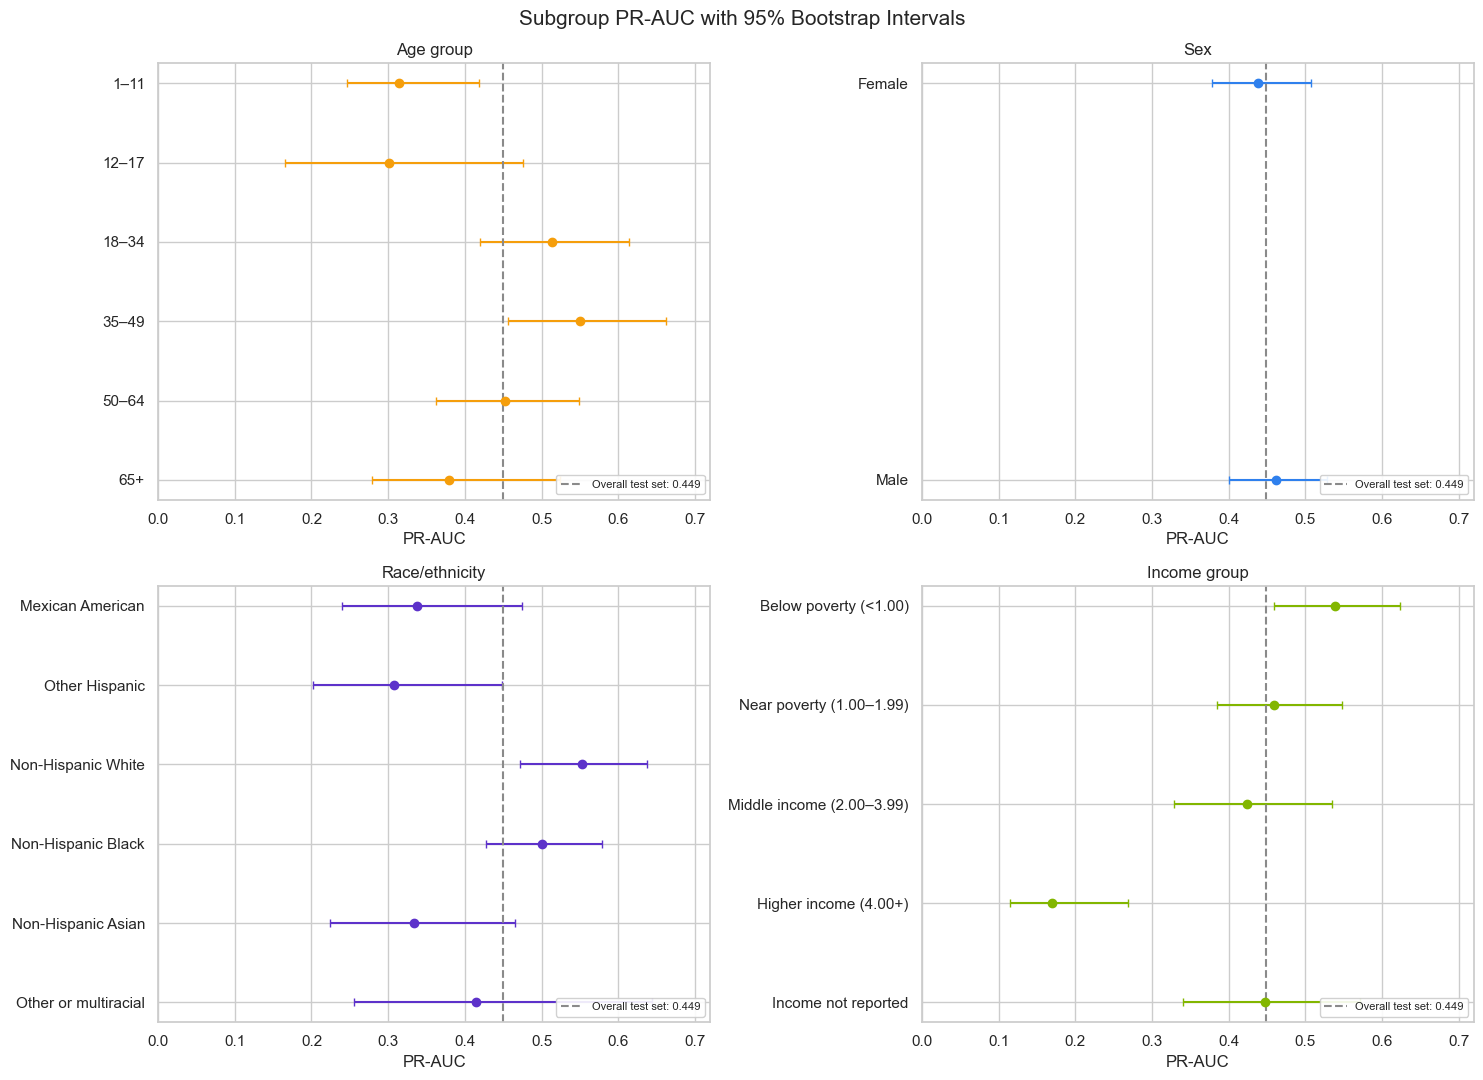

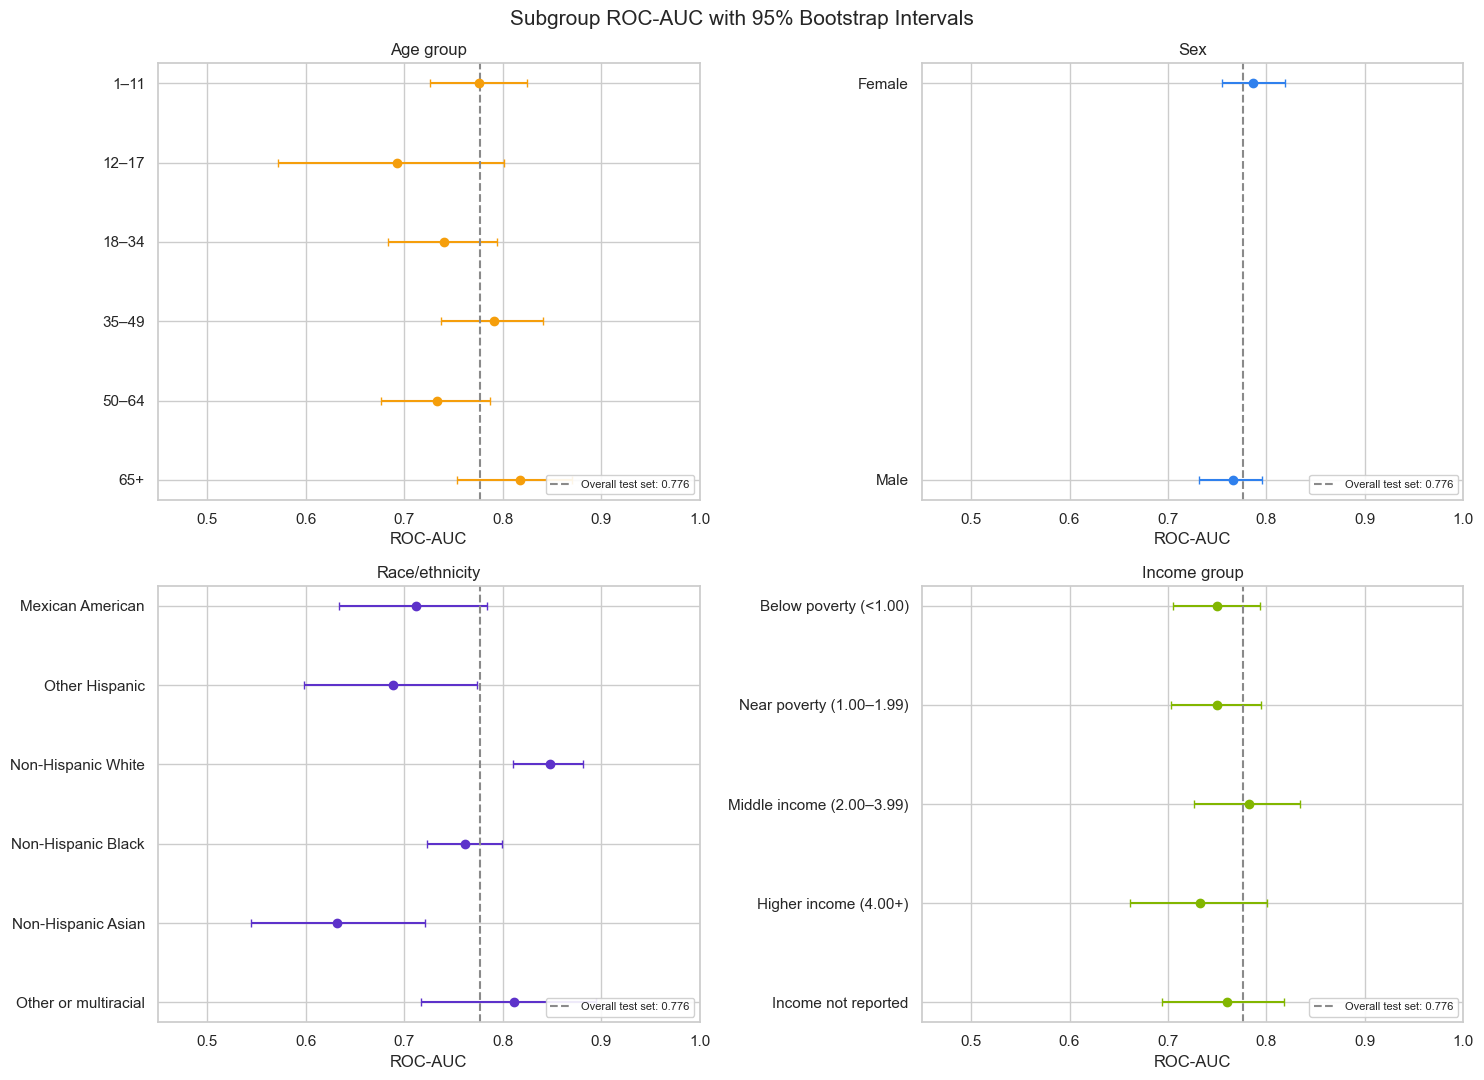

In [85]:
plot_single_metric(
    metric="PR-AUC",
    title="Subgroup PR-AUC with 95% Bootstrap Intervals",
    reference=overall_metrics["PR-AUC"],
    xlim=(0, 0.72),
)
plot_single_metric(
    metric="ROC-AUC",
    title="Subgroup ROC-AUC with 95% Bootstrap Intervals",
    reference=overall_metrics["ROC-AUC"],
    xlim=(0.45, 1.0),
)


In [86]:
lowest_roc = subgroup_point_results.nsmallest(1, "ROC-AUC").iloc[0]
highest_roc = subgroup_point_results.nlargest(1, "ROC-AUC").iloc[0]
lowest_pr_skill = subgroup_point_results.nsmallest(
    1,
    "PR-AUC skill",
).iloc[0]

display(
    Markdown(
        f"Subgroup ROC-AUC ranges from **{lowest_roc['ROC-AUC']:.3f}** "
        f"for **{lowest_roc['Group']}** to "
        f"**{highest_roc['ROC-AUC']:.3f}** for "
        f"**{highest_roc['Group']}**. The smallest normalized "
        f"PR-AUC skill is **{lowest_pr_skill['PR-AUC skill']:.3f}** "
        f"for **{lowest_pr_skill['Group']}**. These estimates "
        "describe ranking within each group; they do not yet show "
        "whether the frozen 0.130 screening decision works equally "
        "well."
    )
)


Subgroup ROC-AUC ranges from **0.631** for **Non-Hispanic Asian** to **0.848** for **Non-Hispanic White**. The smallest normalized PR-AUC skill is **0.099** for **Higher income (4.00+)**. These estimates describe ranking within each group; they do not yet show whether the frozen 0.130 screening decision works equally well.

## Does Self-Rated Teeth Condition Behave Similarly Across Race/Ethnicity?

Notebook 6 showed that self-rated teeth condition is the model's dominant predictor. If the connection between that rating and actual cavities differs across groups, the same feature may carry less ranking information in some groups.

This diagnostic uses the **training cohort only** and reports cavity prevalence at each self-rating level. It can identify a plausible mechanism, but it cannot establish that culture, language, access, or any other factor caused the pattern.


In [87]:
def build_subgroup_labels(source_data):
    # Rebuild exactly the same four labels for another project file.
    labels = pd.DataFrame(index=source_data.index)
    labels["Age group"] = pd.cut(
        source_data["age"],
        bins=[0, 12, 18, 35, 50, 65, np.inf],
        labels=age_order,
        right=False,
    )
    labels["Sex"] = pd.Categorical(
        np.where(
            source_data["sex_female"].eq(1),
            "Female",
            "Male",
        ),
        categories=sex_order,
        ordered=True,
    )

    race_values = np.full(
        len(source_data),
        "Non-Hispanic White",
        dtype=object,
    )
    for column, label in race_columns.items():
        race_values[
            source_data[column].eq(1).to_numpy()
        ] = label
    labels["Race/ethnicity"] = pd.Categorical(
        race_values,
        categories=race_order,
        ordered=True,
    )

    income_values = np.full(len(source_data), "", dtype=object)
    missing = source_data[
        "income_poverty_ratio_missing"
    ].eq(1)
    observed = ~missing
    ratio = source_data["income_poverty_ratio"]

    income_values[missing.to_numpy()] = "Income not reported"
    income_values[(observed & ratio.lt(1)).to_numpy()] = (
        "Below poverty (<1.00)"
    )
    income_values[
        (observed & ratio.ge(1) & ratio.lt(2)).to_numpy()
    ] = "Near poverty (1.00–1.99)"
    income_values[
        (observed & ratio.ge(2) & ratio.lt(4)).to_numpy()
    ] = "Middle income (2.00–3.99)"
    income_values[(observed & ratio.ge(4)).to_numpy()] = (
        "Higher income (4.00+)"
    )
    assert (income_values != "").all()
    labels["Income group"] = pd.Categorical(
        income_values,
        categories=income_order,
        ordered=True,
    )
    return labels


# Stop if the reusable label function does not reproduce the test
# labels already displayed earlier in this notebook.
regenerated_test_groups = build_subgroup_labels(test_data)
for dimension in group_order:
    assert np.array_equal(
        regenerated_test_groups[dimension].astype(str),
        analysis_data[dimension].astype(str),
    )

training_group_labels = build_subgroup_labels(training_data)
training_with_groups = pd.concat(
    [
        training_data.reset_index(drop=True),
        training_group_labels.reset_index(drop=True),
    ],
    axis=1,
)

self_rating_by_race = (
    training_with_groups.groupby(
        ["Race/ethnicity", "teeth_condition_ord"],
        observed=True,
    )["has_cavity"]
    .agg(Cavity_prevalence="mean", Participants="size", Cases="sum")
    .reset_index()
)

self_rating_by_race.round(
    {"Cavity_prevalence": 3}
)


,Race/ethnicity,teeth_condition_ord,Cavity_prevalence,Participants,Cases
0,Mexican American,1,0.089,191,17
1,Mexican American,2,0.098,235,23
2,Mexican American,3,0.170,471,80
3,Mexican American,4,0.251,338,85
4,Mexican American,5,0.386,101,39
5,Other Hispanic,1,0.076,172,13
6,Other Hispanic,2,0.113,231,26
7,Other Hispanic,3,0.165,364,60
8,Other Hispanic,4,0.286,217,62
9,Other Hispanic,5,0.431,65,28


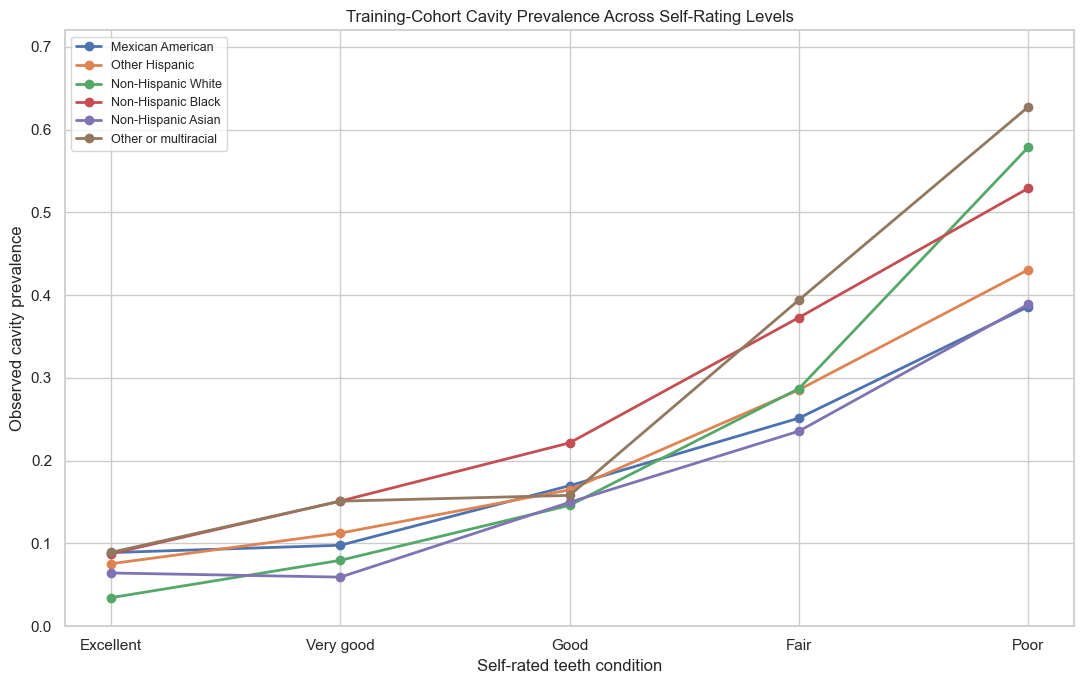

Cavity prevalence rises as self-rating worsens in every displayed group, so the feature retains the correct direction. The excellent-to-poor increase is **0.325** for non-Hispanic Asian participants and **0.544** for non-Hispanic White participants. That difference is a plausible clue for why ranking may be weaker, but the poorest-rating Asian cell contains only **36 participants**. It is not enough to establish measurement nonequivalence or a cause.

In [88]:
plt.figure(figsize=(11, 7))
for race_name in race_order:
    race_data = self_rating_by_race.loc[
        self_rating_by_race["Race/ethnicity"].eq(race_name)
    ]
    plt.plot(
        race_data["teeth_condition_ord"],
        race_data["Cavity_prevalence"],
        marker="o",
        linewidth=2,
        label=race_name,
    )

plt.xticks(
    [1, 2, 3, 4, 5],
    ["Excellent", "Very good", "Good", "Fair", "Poor"],
)
plt.xlabel("Self-rated teeth condition")
plt.ylabel("Observed cavity prevalence")
plt.title(
    "Training-Cohort Cavity Prevalence Across Self-Rating Levels"
)
plt.ylim(0, 0.72)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

rating_extremes = (
    self_rating_by_race.loc[
        self_rating_by_race["teeth_condition_ord"].isin([1, 5])
    ]
    .pivot(
        index="Race/ethnicity",
        columns="teeth_condition_ord",
        values="Cavity_prevalence",
    )
    .rename(columns={1: "Excellent", 5: "Poor"})
)
rating_extremes["Poor minus excellent"] = (
    rating_extremes["Poor"] - rating_extremes["Excellent"]
)

asian_span = rating_extremes.loc[
    "Non-Hispanic Asian", "Poor minus excellent"
]
white_span = rating_extremes.loc[
    "Non-Hispanic White", "Poor minus excellent"
]
asian_poor_n = self_rating_by_race.loc[
    self_rating_by_race["Race/ethnicity"].eq(
        "Non-Hispanic Asian"
    )
    & self_rating_by_race["teeth_condition_ord"].eq(5),
    "Participants",
].iloc[0]

display(
    Markdown(
        "Cavity prevalence rises as self-rating worsens in every "
        "displayed group, so the feature retains the correct "
        "direction. The excellent-to-poor increase is "
        f"**{asian_span:.3f}** for non-Hispanic Asian participants "
        f"and **{white_span:.3f}** for non-Hispanic White "
        "participants. That difference is a plausible clue for "
        "why ranking may be weaker, but the poorest-rating Asian "
        f"cell contains only **{asian_poor_n} participants**. It is "
        "not enough to establish measurement nonequivalence or a "
        "cause."
    )
)


## Applying the Frozen Screening Threshold


The 0.130 threshold was selected from out-of-fold training predictions to support approximately 80% overall recall. It is applied unchanged to every participant here.

**Recall** is the central screening metric because it measures the share of actual cavities caught. **Specificity** shows the share of participants without cavities who are not flagged, while **precision** shows how many flagged participants actually have a cavity. Precision naturally changes with prevalence, so it should not be read as a fairness measure by itself.


In [89]:
threshold_intervals = {}
for metric in ["Recall", "Specificity", "Precision"]:
    threshold_intervals[metric] = interval_lookup(metric).rename(
        columns={
            "Estimate": f"{metric} estimate",
            "Lower 95%": f"{metric} lower 95%",
            "Upper 95%": f"{metric} upper 95%",
        }
    )[
        [
            "Dimension",
            "Group",
            f"{metric} estimate",
            f"{metric} lower 95%",
            f"{metric} upper 95%",
        ]
    ]

threshold_table = subgroup_point_results[
    [
        "Dimension",
        "Group",
        "Participants",
        "Cavity cases",
        "Recall",
        "Specificity",
        "Precision",
        "Share flagged",
        "True positives",
        "False negatives",
        "False positives",
        "True negatives",
    ]
].copy()

for metric in ["Recall", "Specificity", "Precision"]:
    threshold_table = threshold_table.merge(
        threshold_intervals[metric],
        on=["Dimension", "Group"],
        how="left",
        validate="one_to_one",
    )

threshold_table.round(3)


,Dimension,Group,Participants,Cavity cases,Recall,Specificity,Precision,Share flagged,True positives,False negatives,False positives,True negatives,Recall estimate,Recall lower 95%,Recall upper 95%,Specificity estimate,Specificity lower 95%,Specificity upper 95%,Precision estimate,Precision lower 95%,Precision upper 95%
0,Age group,1–11,658,88,0.716,0.649,0.240,0.400,63,25,200,370,0.716,0.615,0.812,0.649,0.610,0.687,0.240,0.188,0.295
1,Age group,12–17,294,30,0.633,0.689,0.188,0.344,19,11,82,182,0.633,0.448,0.810,0.689,0.633,0.744,0.188,0.114,0.265
2,Age group,18–34,474,111,0.865,0.399,0.306,0.662,96,15,218,145,0.865,0.798,0.928,0.399,0.350,0.448,0.306,0.255,0.357
3,Age group,35–49,369,99,0.919,0.389,0.355,0.694,91,8,165,105,0.919,0.861,0.970,0.389,0.329,0.448,0.355,0.297,0.414
4,Age group,50–64,449,103,0.816,0.480,0.318,0.588,84,19,180,166,0.816,0.735,0.892,0.480,0.428,0.529,0.318,0.264,0.376
5,Age group,65+,399,53,0.811,0.662,0.269,0.401,43,10,117,229,0.811,0.696,0.911,0.662,0.611,0.712,0.269,0.201,0.333
6,Sex,Female,1342,230,0.809,0.592,0.291,0.477,186,44,454,658,0.809,0.756,0.859,0.592,0.563,0.620,0.291,0.256,0.325
7,Sex,Male,1301,254,0.827,0.515,0.292,0.552,210,44,508,539,0.827,0.778,0.872,0.515,0.483,0.545,0.292,0.259,0.325
8,Race/ethnicity,Mexican American,349,56,0.768,0.509,0.230,0.536,43,13,144,149,0.768,0.649,0.873,0.509,0.451,0.563,0.230,0.169,0.291
9,Race/ethnicity,Other Hispanic,238,39,0.718,0.518,0.226,0.521,28,11,96,103,0.718,0.568,0.857,0.518,0.450,0.589,0.226,0.157,0.305


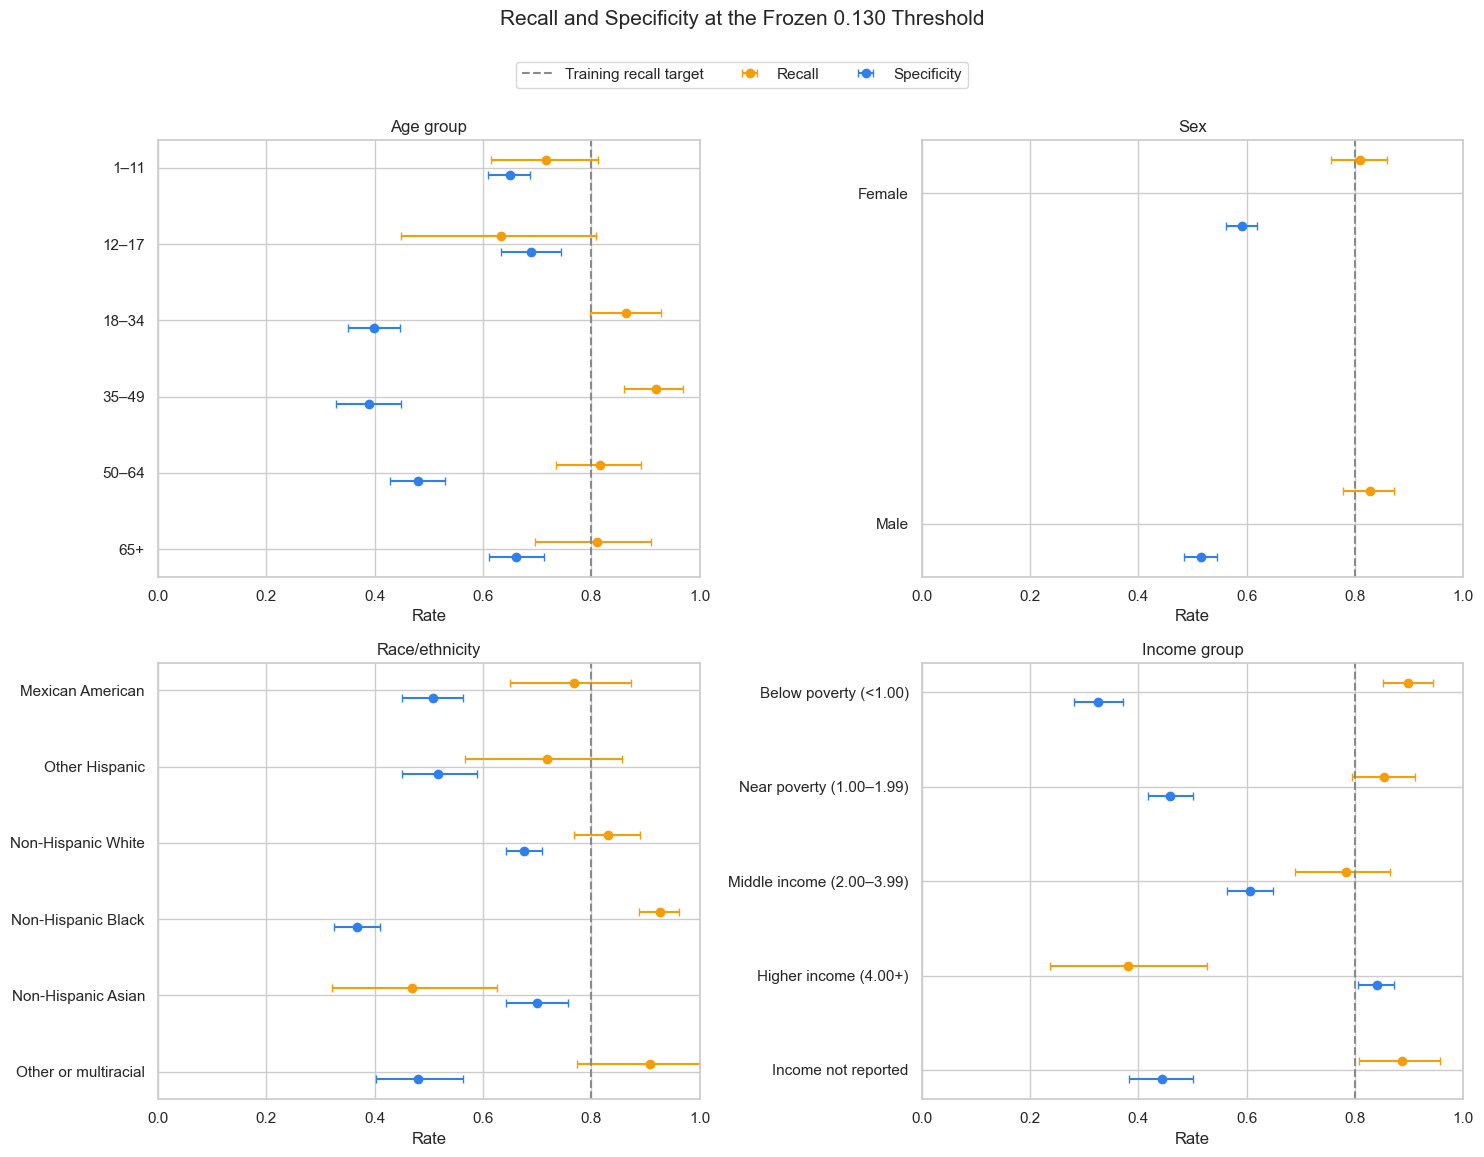

In [90]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11))

for axis, (dimension, ordered_groups) in zip(
    axes.flat,
    group_order.items(),
):
    recall_panel = (
        interval_lookup("Recall")
        .loc[lambda data: data["Dimension"].eq(dimension)]
        .set_index("Group")
        .loc[ordered_groups]
        .reset_index()
    )
    specificity_panel = (
        interval_lookup("Specificity")
        .loc[lambda data: data["Dimension"].eq(dimension)]
        .set_index("Group")
        .loc[ordered_groups]
        .reset_index()
    )
    y_positions = np.arange(len(ordered_groups))

    for panel, metric, color, offset in [
        (recall_panel, "Recall", ORANGE, -0.10),
        (specificity_panel, "Specificity", BLUE, 0.10),
    ]:
        axis.errorbar(
            panel["Estimate"],
            y_positions + offset,
            xerr=np.vstack(
                [
                    panel["Estimate"] - panel["Lower 95%"],
                    panel["Upper 95%"] - panel["Estimate"],
                ]
            ),
            fmt="o",
            color=color,
            ecolor=color,
            capsize=3,
            label=metric,
        )

    axis.axvline(
        0.80,
        color=GRAY,
        linestyle="--",
        linewidth=1.5,
        label="Training recall target",
    )
    axis.set_yticks(y_positions)
    axis.set_yticklabels(ordered_groups)
    axis.invert_yaxis()
    axis.set_xlim(0, 1)
    axis.set_xlabel("Rate")
    axis.set_title(dimension)

handles, labels = axes[0, 0].get_legend_handles_labels()
figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)
figure.suptitle(
    "Recall and Specificity at the Frozen 0.130 Threshold",
    y=1.05,
    fontsize=15,
)
plt.tight_layout()
plt.show()


In [91]:
below_target = subgroup_point_results.loc[
    subgroup_point_results["Recall"].lt(0.80)
].sort_values("Recall")
lowest_recall = below_target.iloc[0]

below_target_list = ", ".join(
    f"{row.Group} ({row.Recall:.3f})"
    for row in below_target.itertuples()
)

display(
    Markdown(
        f"The frozen threshold falls below 0.80 recall in "
        f"**{len(below_target)} displayed groups**: "
        f"{below_target_list}. The lowest point estimate is "
        f"**{lowest_recall['Recall']:.3f}** for "
        f"**{lowest_recall['Group']}**, where the model catches "
        f"{int(lowest_recall['True positives'])} of "
        f"{int(lowest_recall['Cavity cases'])} cavities and misses "
        f"{int(lowest_recall['False negatives'])}. The 80% value was "
        "an overall training rule, not a promise that every subgroup "
        "would independently reach that recall. The next section "
        "separates shortfalls caused mainly by threshold placement "
        "from shortfalls that remain because ranking is weaker."
    )
)


The frozen threshold falls below 0.80 recall in **7 displayed groups**: Higher income (4.00+) (0.381), Non-Hispanic Asian (0.468), 12–17 (0.633), 1–11 (0.716), Other Hispanic (0.718), Mexican American (0.768), Middle income (2.00–3.99) (0.784). The lowest point estimate is **0.381** for **Higher income (4.00+)**, where the model catches 16 of 42 cavities and misses 26. The 80% value was an overall training rule, not a promise that every subgroup would independently reach that recall. The next section separates shortfalls caused mainly by threshold placement from shortfalls that remain because ranking is weaker.

## Separating the Operating Point from Ranking Quality

A low recall at 0.130 can happen for two different reasons:

1. The model still ranks participants reasonably well, but the global threshold sits too high inside that group's probability distribution.
2. The model has weak within-group ranking, so moving the threshold can only gain recall by flagging a very large share of the group.

Two diagnostics separate those mechanisms:

- **Matched flag share:** within each group, lower or raise the cutoff until approximately the same 51.4% share is flagged as in the overall test set. This threshold uses test probabilities but not test outcomes. It is descriptive and is never adopted.
- **Training-derived subgroup threshold:** apply Notebook 4's Wilson-supported 80% recall rule separately to each subgroup using only out-of-fold **training** probabilities, then evaluate that frozen sensitivity threshold on the test group.

These are counterfactual analyses, not new deployment rules. The four dimensions overlap, so their thresholds could not all be applied simultaneously. Using a different threshold based on income or race would also require clinical, ethical, legal, and operational review.


In [92]:
TARGET_RECALL = 0.80
Z_95 = 1.959964
candidate_thresholds = np.round(
    np.arange(0.0, 0.951, 0.005),
    3,
)


def wilson_lower_bound(successes, trials, z=Z_95):
    # Same conservative proportion interval used in Notebook 4.
    if trials == 0:
        return 0.0
    proportion = successes / trials
    denominator = 1 + z**2 / trials
    center = (
        proportion + z**2 / (2 * trials)
    ) / denominator
    margin = (
        z
        * np.sqrt(
            proportion * (1 - proportion) / trials
            + z**2 / (4 * trials**2)
        )
    ) / denominator
    return center - margin


def select_supported_recall_threshold(labels, probabilities):
    # Take the highest cutoff whose recall lower bound still
    # clears 80%, minimizing referrals among qualifying cutoffs.
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    total_cases = int(labels.sum())
    rows = []

    for threshold in candidate_thresholds:
        predictions = probabilities >= threshold
        caught = int((predictions & labels.astype(bool)).sum())
        recall = caught / total_cases
        rows.append(
            {
                "Threshold": threshold,
                "Development recall": recall,
                "Recall lower 95%": wilson_lower_bound(
                    caught,
                    total_cases,
                ),
                "Development share flagged": predictions.mean(),
            }
        )

    candidates = pd.DataFrame(rows)
    qualifying = candidates.loc[
        candidates["Recall lower 95%"] >= TARGET_RECALL
    ]
    if qualifying.empty:
        return candidates.iloc[0], False
    return qualifying.loc[qualifying["Threshold"].idxmax()], True


# Join by participant identifier so the out-of-fold probabilities
# can never silently shift away from their true training outcomes.
training_oof = training_with_groups.merge(
    out_of_fold_predictions[
        ["SEQN", "has_cavity", "Gradient Boosting"]
    ],
    on=["SEQN", "has_cavity"],
    how="inner",
    validate="one_to_one",
).rename(columns={"Gradient Boosting": "Probability"})
assert len(training_oof) == len(training_data)

operating_rows = []
overall_flag_share = overall_metrics["Share flagged"]

for dimension, ordered_groups in group_order.items():
    for group_name in ordered_groups:
        development_group = training_oof.loc[
            training_oof[dimension].eq(group_name)
        ]
        test_group = analysis_data.loc[
            analysis_data[dimension].eq(group_name)
        ].copy()

        selected, floor_met = select_supported_recall_threshold(
            development_group["has_cavity"],
            development_group["Probability"],
        )

        development_threshold = float(selected["Threshold"])
        development_test = test_group.copy()
        development_test["Prediction"] = (
            development_test["Probability"]
            >= development_threshold
        ).astype(int)
        development_test_metrics = calculate_metrics(
            development_test
        )

        # This cutoff flags approximately the same fraction of
        # each group as the global rule flags overall. It is useful
        # for diagnosis but is not a proposed quota policy.
        matched_threshold = float(
            np.quantile(
                test_group["Probability"],
                1 - overall_flag_share,
                method="linear",
            )
        )
        matched_test = test_group.copy()
        matched_test["Prediction"] = (
            matched_test["Probability"] >= matched_threshold
        ).astype(int)
        matched_test_metrics = calculate_metrics(matched_test)

        frozen_row = subgroup_point_results.loc[
            subgroup_point_results["Dimension"].eq(dimension)
            & subgroup_point_results["Group"].eq(group_name)
        ].iloc[0]

        operating_rows.append(
            {
                "Dimension": dimension,
                "Group": group_name,
                "Development cavity cases": int(
                    development_group["has_cavity"].sum()
                ),
                "ROC-AUC": frozen_row["ROC-AUC"],
                "Frozen threshold": primary_threshold,
                "Frozen recall": frozen_row["Recall"],
                "Frozen specificity": frozen_row["Specificity"],
                "Frozen share flagged": frozen_row["Share flagged"],
                "OOF subgroup threshold": development_threshold,
                "OOF recall lower 95%": selected[
                    "Recall lower 95%"
                ],
                "OOF floor met": floor_met,
                "Test recall at OOF threshold": (
                    development_test_metrics["Recall"]
                ),
                "Test specificity at OOF threshold": (
                    development_test_metrics["Specificity"]
                ),
                "Test share flagged at OOF threshold": (
                    development_test_metrics["Share flagged"]
                ),
                "Matched-share threshold": matched_threshold,
                "Test recall at matched share": (
                    matched_test_metrics["Recall"]
                ),
                "Test specificity at matched share": (
                    matched_test_metrics["Specificity"]
                ),
                "Matched test share flagged": (
                    matched_test_metrics["Share flagged"]
                ),
            }
        )

operating_point_diagnostics = pd.DataFrame(operating_rows)
assert operating_point_diagnostics["OOF floor met"].all()
operating_point_diagnostics.round(3)


,Dimension,Group,Development cavity cases,ROC-AUC,Frozen threshold,Frozen recall,Frozen specificity,Frozen share flagged,OOF subgroup threshold,OOF recall lower 95%,OOF floor met,Test recall at OOF threshold,Test specificity at OOF threshold,Test share flagged at OOF threshold,Matched-share threshold,Test recall at matched share,Test specificity at matched share,Matched test share flagged
0,Age group,1–11,363,0.776,0.13,0.716,0.649,0.400,0.095,0.805,True,0.875,0.495,0.555,0.105,0.818,0.533,0.514
1,Age group,12–17,118,0.693,0.13,0.633,0.689,0.344,0.060,0.811,True,0.900,0.239,0.776,0.101,0.700,0.508,0.514
2,Age group,18–34,449,0.740,0.13,0.865,0.399,0.662,0.170,0.805,True,0.775,0.523,0.546,0.182,0.730,0.551,0.515
3,Age group,35–49,385,0.791,0.13,0.919,0.389,0.694,0.175,0.813,True,0.889,0.533,0.580,0.206,0.869,0.615,0.515
4,Age group,50–64,376,0.733,0.13,0.816,0.480,0.588,0.140,0.803,True,0.806,0.523,0.552,0.154,0.786,0.566,0.514
5,Age group,65+,245,0.817,0.13,0.811,0.662,0.401,0.070,0.835,True,0.962,0.376,0.669,0.100,0.887,0.543,0.514
6,Sex,Female,924,0.787,0.13,0.809,0.592,0.477,0.115,0.812,True,0.843,0.531,0.533,0.120,0.830,0.551,0.514
7,Sex,Male,1012,0.766,0.13,0.827,0.515,0.552,0.130,0.810,True,0.827,0.515,0.552,0.143,0.823,0.562,0.513
8,Race/ethnicity,Mexican American,244,0.712,0.13,0.768,0.509,0.536,0.105,0.816,True,0.804,0.423,0.613,0.141,0.768,0.536,0.513
9,Race/ethnicity,Other Hispanic,189,0.689,0.13,0.718,0.518,0.521,0.110,0.818,True,0.769,0.447,0.588,0.133,0.692,0.523,0.513


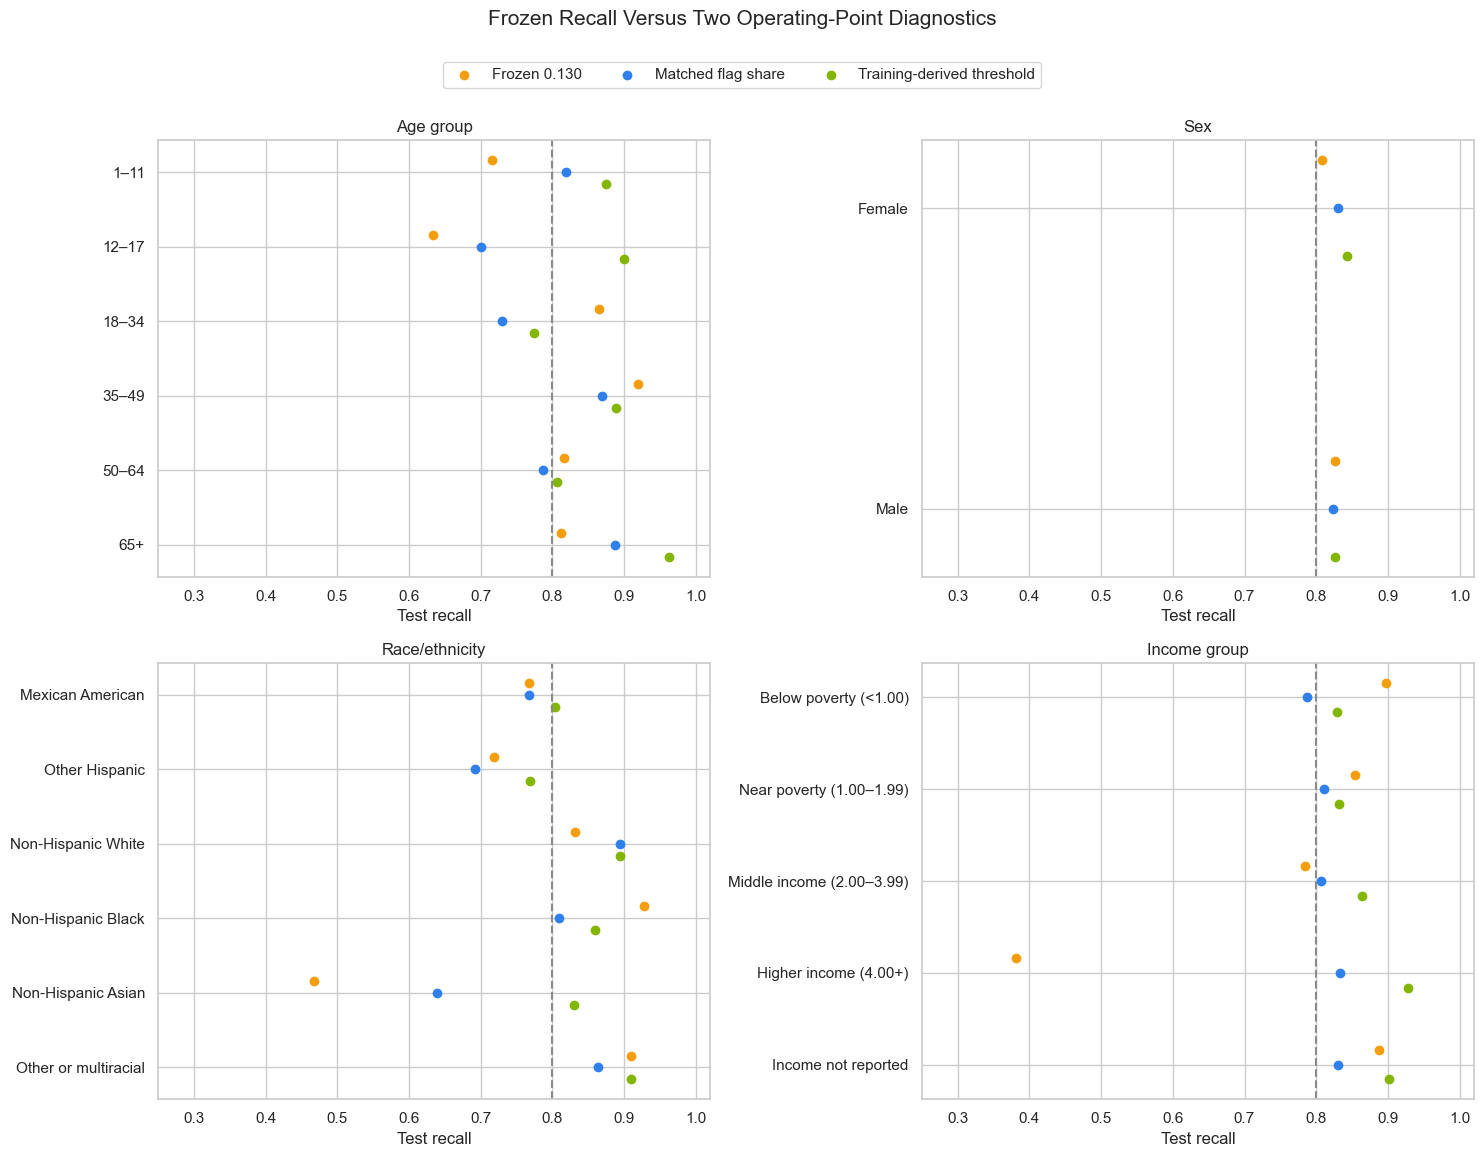

In [93]:
figure, axes = plt.subplots(2, 2, figsize=(15, 11))

for axis, (dimension, ordered_groups) in zip(
    axes.flat,
    group_order.items(),
):
    panel = (
        operating_point_diagnostics.loc[
            operating_point_diagnostics["Dimension"].eq(dimension)
        ]
        .set_index("Group")
        .loc[ordered_groups]
        .reset_index()
    )
    y_positions = np.arange(len(panel))

    axis.scatter(
        panel["Frozen recall"],
        y_positions - 0.16,
        color=ORANGE,
        label="Frozen 0.130",
    )
    axis.scatter(
        panel["Test recall at matched share"],
        y_positions,
        color=BLUE,
        label="Matched flag share",
    )
    axis.scatter(
        panel["Test recall at OOF threshold"],
        y_positions + 0.16,
        color=GREEN,
        label="Training-derived threshold",
    )
    axis.axvline(
        TARGET_RECALL,
        color=GRAY,
        linestyle="--",
        linewidth=1.5,
    )
    axis.set_yticks(y_positions)
    axis.set_yticklabels(ordered_groups)
    axis.invert_yaxis()
    axis.set_xlim(0.25, 1.02)
    axis.set_xlabel("Test recall")
    axis.set_title(dimension)

handles, labels = axes[0, 0].get_legend_handles_labels()
figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)
figure.suptitle(
    "Frozen Recall Versus Two Operating-Point Diagnostics",
    y=1.05,
    fontsize=15,
)
plt.tight_layout()
plt.show()


In [94]:
higher_income_diagnostic = operating_point_diagnostics.loc[
    operating_point_diagnostics["Group"].eq(
        "Higher income (4.00+)"
    )
].iloc[0]
asian_diagnostic = operating_point_diagnostics.loc[
    operating_point_diagnostics["Group"].eq(
        "Non-Hispanic Asian"
    )
].iloc[0]

display(
    Markdown(
        "For **Higher income (4.00+)**, the frozen threshold "
        f"produces {higher_income_diagnostic['Frozen recall']:.3f} "
        "recall while flagging only "
        f"{higher_income_diagnostic['Frozen share flagged']:.1%}. "
        "At the matched overall flag share, recall rises to "
        f"**{higher_income_diagnostic['Test recall at matched share']:.3f}**. "
        "The threshold selected from subgroup out-of-fold training "
        "predictions is "
        f"**{higher_income_diagnostic['OOF subgroup threshold']:.3f}**; "
        "on the test group it reaches "
        f"**{higher_income_diagnostic['Test recall at OOF threshold']:.3f} "
        "recall** but flags "
        f"**{higher_income_diagnostic['Test share flagged at OOF threshold']:.1%}**. "
        "That large referral increase shows why a lower cutoff is "
        "an operating-policy trade-off, not a free model fix. The "
        "training rule requires the **lower Wilson confidence bound** "
        "to reach 0.80; it does not aim for a test point estimate of "
        "exactly 0.80. Test recall can therefore overshoot the target "
        "by design, especially in smaller subgroups.\n\n"
        "For **Non-Hispanic Asian** participants, matched-share "
        "recall rises only to "
        f"**{asian_diagnostic['Test recall at matched share']:.3f}**, "
        "while ROC-AUC remains "
        f"**{asian_diagnostic['ROC-AUC']:.3f}**. Lowering a "
        "threshold can force recall upward by referring more "
        "people, but it cannot repair weaker ranking."
    )
)


For **Higher income (4.00+)**, the frozen threshold produces 0.381 recall while flagging only 17.7%. At the matched overall flag share, recall rises to **0.833**. The threshold selected from subgroup out-of-fold training predictions is **0.045**; on the test group it reaches **0.929 recall** but flags **66.7%**. That large referral increase shows why a lower cutoff is an operating-policy trade-off, not a free model fix. The training rule requires the **lower Wilson confidence bound** to reach 0.80; it does not aim for a test point estimate of exactly 0.80. Test recall can therefore overshoot the target by design, especially in smaller subgroups.

For **Non-Hispanic Asian** participants, matched-share recall rises only to **0.638**, while ROC-AUC remains **0.631**. Lowering a threshold can force recall upward by referring more people, but it cannot repair weaker ranking.

## Looking Directly at the Error Burden


In [95]:
error_table = subgroup_point_results[
    [
        "Dimension",
        "Group",
        "Participants",
        "Cavity cases",
        "True positives",
        "False negatives",
        "False positives",
        "True negatives",
        "False-negative rate",
        "False-positive rate",
        "Share flagged",
    ]
].copy()

error_table.sort_values(
    ["Dimension", "False-negative rate"],
    ascending=[True, False],
).round(3)


,Dimension,Group,Participants,Cavity cases,True positives,False negatives,False positives,True negatives,False-negative rate,False-positive rate,Share flagged
1,Age group,12–17,294,30,19,11,82,182,0.367,0.311,0.344
0,Age group,1–11,658,88,63,25,200,370,0.284,0.351,0.400
5,Age group,65+,399,53,43,10,117,229,0.189,0.338,0.401
4,Age group,50–64,449,103,84,19,180,166,0.184,0.520,0.588
2,Age group,18–34,474,111,96,15,218,145,0.135,0.601,0.662
3,Age group,35–49,369,99,91,8,165,105,0.081,0.611,0.694
17,Income group,Higher income (4.00+),537,42,16,26,79,416,0.619,0.160,0.177
16,Income group,Middle income (2.00–3.99),598,88,69,19,201,309,0.216,0.394,0.452
15,Income group,Near poverty (1.00–1.99),625,137,117,20,264,224,0.146,0.541,0.610
18,Income group,Income not reported,335,71,63,8,147,117,0.113,0.557,0.627


In [96]:
highest_false_positive_rate = subgroup_point_results.nlargest(
    1,
    "False-positive rate",
).iloc[0]
highest_flagged_share = subgroup_point_results.nlargest(
    1,
    "Share flagged",
).iloc[0]

display(
    Markdown(
        f"The largest false-positive-rate point estimate is "
        f"**{highest_false_positive_rate['False-positive rate']:.3f}** "
        f"for **{highest_false_positive_rate['Group']}**. The largest "
        f"share flagged is **{highest_flagged_share['Share flagged']:.1%}** "
        f"for **{highest_flagged_share['Group']}**. High recall can "
        "therefore come with a substantial referral burden. Counts and "
        "rates are both shown because a small rate in a large group can "
        "still represent many participants."
    )
)


The largest false-positive-rate point estimate is **0.674** for **Below poverty (<1.00)**. The largest share flagged is **73.4%** for **Below poverty (<1.00)**. High recall can therefore come with a substantial referral burden. Counts and rates are both shown because a small rate in a large group can still represent many participants.

## Calibration Within Each Group


Calibration asks whether predicted probabilities agree with observed frequencies. The first check is **calibration-in-the-large**: mean predicted probability minus observed prevalence.

- A gap near 0 indicates agreement on average.
- A negative gap means the model underpredicts that group's observed prevalence.
- A positive gap means the model overpredicts it.

This is the weakest calibration check. A model predicting one constant probability for everyone could pass it while providing no useful ranking. Brier score and Brier skill are therefore shown beside it. Brier skill compares the model with predicting that subgroup's prevalence for everyone: 0 means no improvement and 1 is perfect. Calibration slope and intercept are added afterward only for groups with at least 100 cavity cases, where the estimate is less fragile. Even there, they are descriptive point estimates rather than formal subgroup claims.


In [97]:
calibration_interval = interval_lookup("Calibration gap")
calibration_table = subgroup_point_results[
    [
        "Dimension",
        "Group",
        "Participants",
        "Cavity cases",
        "Prevalence",
        "Mean predicted probability",
        "Calibration gap",
        "Brier score",
        "Brier skill",
    ]
].merge(
    calibration_interval[
        [
            "Dimension",
            "Group",
            "Lower 95%",
            "Upper 95%",
        ]
    ].rename(
        columns={
            "Lower 95%": "Calibration gap lower 95%",
            "Upper 95%": "Calibration gap upper 95%",
        }
    ),
    on=["Dimension", "Group"],
    how="left",
    validate="one_to_one",
)

calibration_table.round(3)


,Dimension,Group,Participants,Cavity cases,Prevalence,Mean predicted probability,Calibration gap,Brier score,Brier skill,Calibration gap lower 95%,Calibration gap upper 95%
0,Age group,1–11,658,88,0.134,0.133,-0.000,0.103,0.108,-0.026,0.023
1,Age group,12–17,294,30,0.102,0.125,0.023,0.085,0.071,-0.011,0.056
2,Age group,18–34,474,111,0.234,0.232,-0.002,0.151,0.158,-0.038,0.034
3,Age group,35–49,369,99,0.268,0.263,-0.005,0.155,0.212,-0.045,0.035
4,Age group,50–64,449,103,0.229,0.200,-0.029,0.157,0.114,-0.067,0.006
5,Age group,65+,399,53,0.133,0.146,0.014,0.097,0.162,-0.016,0.042
6,Sex,Female,1342,230,0.171,0.170,-0.001,0.118,0.167,-0.019,0.017
7,Sex,Male,1301,254,0.195,0.194,-0.001,0.132,0.159,-0.021,0.019
8,Race/ethnicity,Mexican American,349,56,0.160,0.187,0.027,0.124,0.077,-0.012,0.063
9,Race/ethnicity,Other Hispanic,238,39,0.164,0.179,0.015,0.131,0.045,-0.032,0.061


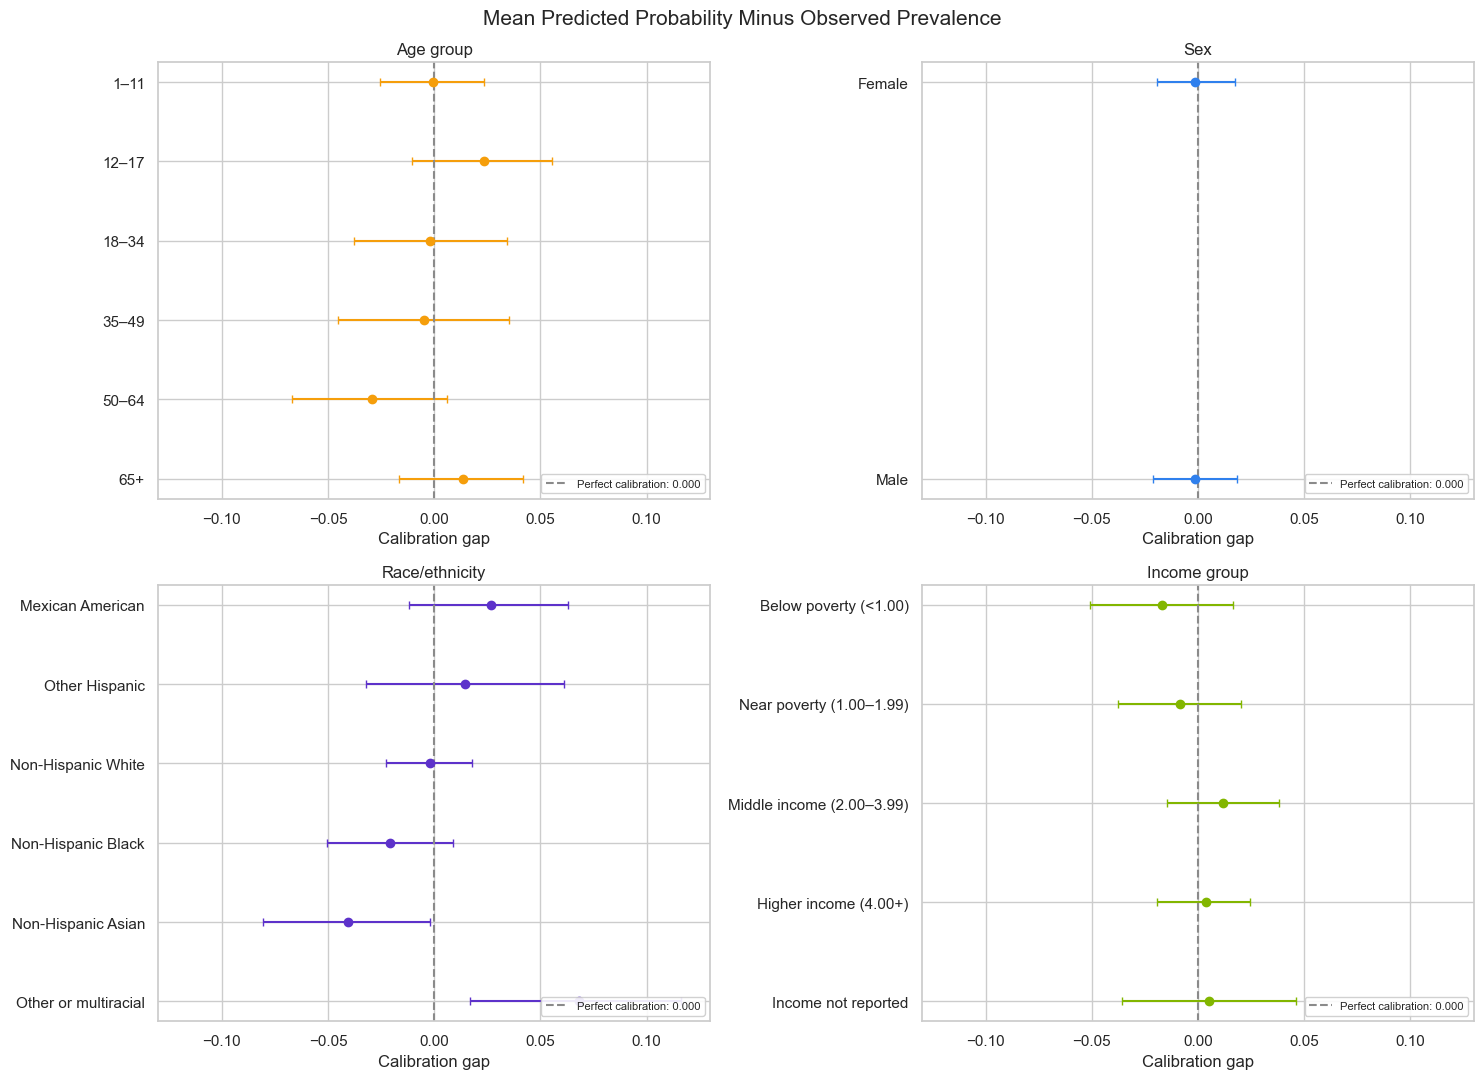

In [98]:
plot_single_metric(
    metric="Calibration gap",
    title="Mean Predicted Probability Minus Observed Prevalence",
    reference=0.0,
    reference_label="Perfect calibration",
    xlim=(-0.13, 0.13),
)


In [99]:
largest_absolute_gap = (
    subgroup_point_results.assign(
        Absolute_gap=lambda data: data["Calibration gap"].abs()
    )
    .nlargest(1, "Absolute_gap")
    .iloc[0]
)
largest_gap_interval = subgroup_intervals.loc[
    subgroup_intervals["Dimension"].eq(
        largest_absolute_gap["Dimension"]
    )
    & subgroup_intervals["Group"].eq(
        largest_absolute_gap["Group"]
    )
    & subgroup_intervals["Metric"].eq("Calibration gap")
].iloc[0]
best_brier_skill = subgroup_point_results.nlargest(
    1,
    "Brier skill",
).iloc[0]
lowest_brier_skill = subgroup_point_results.nsmallest(
    1,
    "Brier skill",
).iloc[0]

gap_direction = (
    "overprediction"
    if largest_absolute_gap["Calibration gap"] > 0
    else "underprediction"
)

display(
    Markdown(
        f"The largest absolute calibration-in-the-large gap is "
        f"**{largest_absolute_gap['Calibration gap']:+.3f}** for "
        f"**{largest_absolute_gap['Group']}** (95% bootstrap interval "
        f"{largest_gap_interval['Lower 95%']:+.3f} to "
        f"{largest_gap_interval['Upper 95%']:+.3f}), indicating "
        f"average {gap_direction}. This is a calibration concern, "
        "whereas the non-Hispanic Asian result later in the notebook "
        "is primarily a ranking concern; the two findings identify "
        "different validation needs rather than competing priorities.\n\n"
        f"Brier skill ranges from **{lowest_brier_skill['Brier skill']:.3f}** "
        f"for **{lowest_brier_skill['Group']}** to "
        f"**{best_brier_skill['Brier skill']:.3f}** for "
        f"**{best_brier_skill['Group']}**. Every displayed value is "
        "above zero, but the improvement over a prevalence-only "
        "probability varies substantially across groups."
    )
)


The largest absolute calibration-in-the-large gap is **+0.068** for **Other or multiracial** (95% bootstrap interval +0.017 to +0.116), indicating average overprediction. This is a calibration concern, whereas the non-Hispanic Asian result later in the notebook is primarily a ranking concern; the two findings identify different validation needs rather than competing priorities.

Brier skill ranges from **0.029** for **Higher income (4.00+)** to **0.254** for **Non-Hispanic White**. Every displayed value is above zero, but the improvement over a prevalence-only probability varies substantially across groups.

### Calibration Slope Where Sample Size Permits

A slope of 1 and intercept of 0 are ideal. A slope below 1 usually means predictions are too extreme; a slope above 1 means they are not extreme enough. These fits are restricted to groups with at least 100 cavity cases and are shown without confidence intervals, so they are supporting diagnostics rather than pass/fail tests.


In [100]:
MIN_CASES_FOR_CALIBRATION_SLOPE = 100
calibration_slope_rows = []

for point_row in subgroup_point_results.to_dict("records"):
    if point_row["Cavity cases"] < MIN_CASES_FOR_CALIBRATION_SLOPE:
        continue

    dimension = point_row["Dimension"]
    group_name = point_row["Group"]
    group_data = analysis_data.loc[
        analysis_data[dimension].eq(group_name)
    ]
    clipped_probability = np.clip(
        group_data["Probability"].to_numpy(),
        1e-6,
        1 - 1e-6,
    )
    predicted_log_odds = logit(clipped_probability).reshape(-1, 1)

    # A very large C makes this effectively unpenalized while
    # avoiding the version-deprecated penalty=None argument.
    recalibration_model = LogisticRegression(
        C=1e12,
        solver="lbfgs",
        max_iter=1_000,
    ).fit(
        predicted_log_odds,
        group_data["has_cavity"],
    )

    calibration_slope_rows.append(
        {
            "Dimension": dimension,
            "Group": group_name,
            "Participants": len(group_data),
            "Cavity cases": int(group_data["has_cavity"].sum()),
            "Calibration intercept": (
                recalibration_model.intercept_[0]
            ),
            "Calibration slope": (
                recalibration_model.coef_[0, 0]
            ),
        }
    )

subgroup_calibration_slopes = pd.DataFrame(
    calibration_slope_rows
)
display(subgroup_calibration_slopes.round(3))

largest_slope_deviation = (
    subgroup_calibration_slopes.assign(
        Deviation=lambda data: (data["Calibration slope"] - 1).abs()
    )
    .nlargest(1, "Deviation")
    .iloc[0]
)
asian_case_count = int(
    subgroup_point_results.loc[
        subgroup_point_results["Group"].eq("Non-Hispanic Asian"),
        "Cavity cases",
    ].iloc[0]
)

display(
    Markdown(
        f"Calibration slopes could be estimated under the prespecified "
        f"case-count rule for **{len(subgroup_calibration_slopes)} of "
        f"{len(subgroup_point_results)} groups**. The largest slope "
        f"departure is for **{largest_slope_deviation['Group']}**: "
        f"slope **{largest_slope_deviation['Calibration slope']:.3f}** "
        f"and intercept "
        f"**{largest_slope_deviation['Calibration intercept']:+.3f}**. "
        "This is worth monitoring, but it remains a descriptive point "
        "estimate without its own confidence interval. Non-Hispanic "
        f"Asian participants have only **{asian_case_count} cavity cases**, "
        "so that priority group cannot support this calibration-slope "
        "analysis in the present test set. That limitation strengthens "
        "the need for a larger external validation sample."
    )
)


,Dimension,Group,Participants,Cavity cases,Calibration intercept,Calibration slope
0,Age group,18–34,474,111,0.015,1.003
1,Age group,50–64,449,103,0.032,0.859
2,Sex,Female,1342,230,0.164,1.116
3,Sex,Male,1301,254,0.058,1.039
4,Race/ethnicity,Non-Hispanic White,903,142,0.547,1.400
5,Race/ethnicity,Non-Hispanic Black,693,178,0.235,1.101
6,Income group,Below poverty (<1.00),548,146,0.198,1.099
7,Income group,Near poverty (1.00–1.99),625,137,0.077,1.016


Calibration slopes could be estimated under the prespecified case-count rule for **8 of 19 groups**. The largest slope departure is for **Non-Hispanic White**: slope **1.400** and intercept **+0.547**. This is worth monitoring, but it remains a descriptive point estimate without its own confidence interval. Non-Hispanic Asian participants have only **47 cavity cases**, so that priority group cannot support this calibration-slope analysis in the present test set. That limitation strengthens the need for a larger external validation sample.

## Paired Differences from Each Group's Complement


The subgroup intervals above answer how uncertain each subgroup estimate is. The paired differences below answer a different question: **how far is each subgroup from everyone outside that group in the same bootstrap resamples?** For reported-income groups, “outside” means the other reported-income groups; the missing-income category is excluded as described earlier.

A difference interval that excludes zero is a more direct descriptive signal than comparing two marginal intervals. With 19 displayed groups, roughly `19 × 0.05 = 0.95` intervals per metric would be expected to exclude zero by chance under a complete null. That is only a rough benchmark because the subgroup comparisons overlap and are not independent. The notebook therefore reports how many intervals exclude zero and how large they are, while still treating them as exploratory rather than multiplicity-corrected hypothesis tests.


In [101]:
key_difference_metrics = [
    "PR-AUC",
    "ROC-AUC",
    "Recall",
    "Specificity",
    "False-positive rate",
    "Calibration gap",
]
key_differences = subgroup_differences.loc[
    subgroup_differences["Metric"].isin(key_difference_metrics)
].copy()

key_differences.sort_values(
    ["Metric", "Difference from complement"]
).round(3)


,Dimension,Group,Metric,Difference from complement,Lower 95%,Upper 95%,Interval excludes zero,Valid resamples
90,Race/ethnicity,Non-Hispanic Asian,Calibration gap,-0.044,-0.087,-0.002,True,2000
34,Age group,50–64,Calibration gap,-0.033,-0.072,0.005,False,2000
83,Race/ethnicity,Non-Hispanic Black,Calibration gap,-0.026,-0.059,0.008,False,2000
104,Income group,Below poverty (<1.00),Calibration gap,-0.019,-0.057,0.018,False,2000
111,Income group,Near poverty (1.00–1.99),Calibration gap,-0.008,-0.042,0.025,False,2000
...,...,...,...,...,...,...,...,...
3,Age group,1–11,Specificity,0.129,0.081,0.175,True,2000
10,Age group,12–17,Specificity,0.154,0.092,0.214,True,2000
87,Race/ethnicity,Non-Hispanic Asian,Specificity,0.165,0.099,0.225,True,2000
73,Race/ethnicity,Non-Hispanic White,Specificity,0.187,0.145,0.230,True,2000


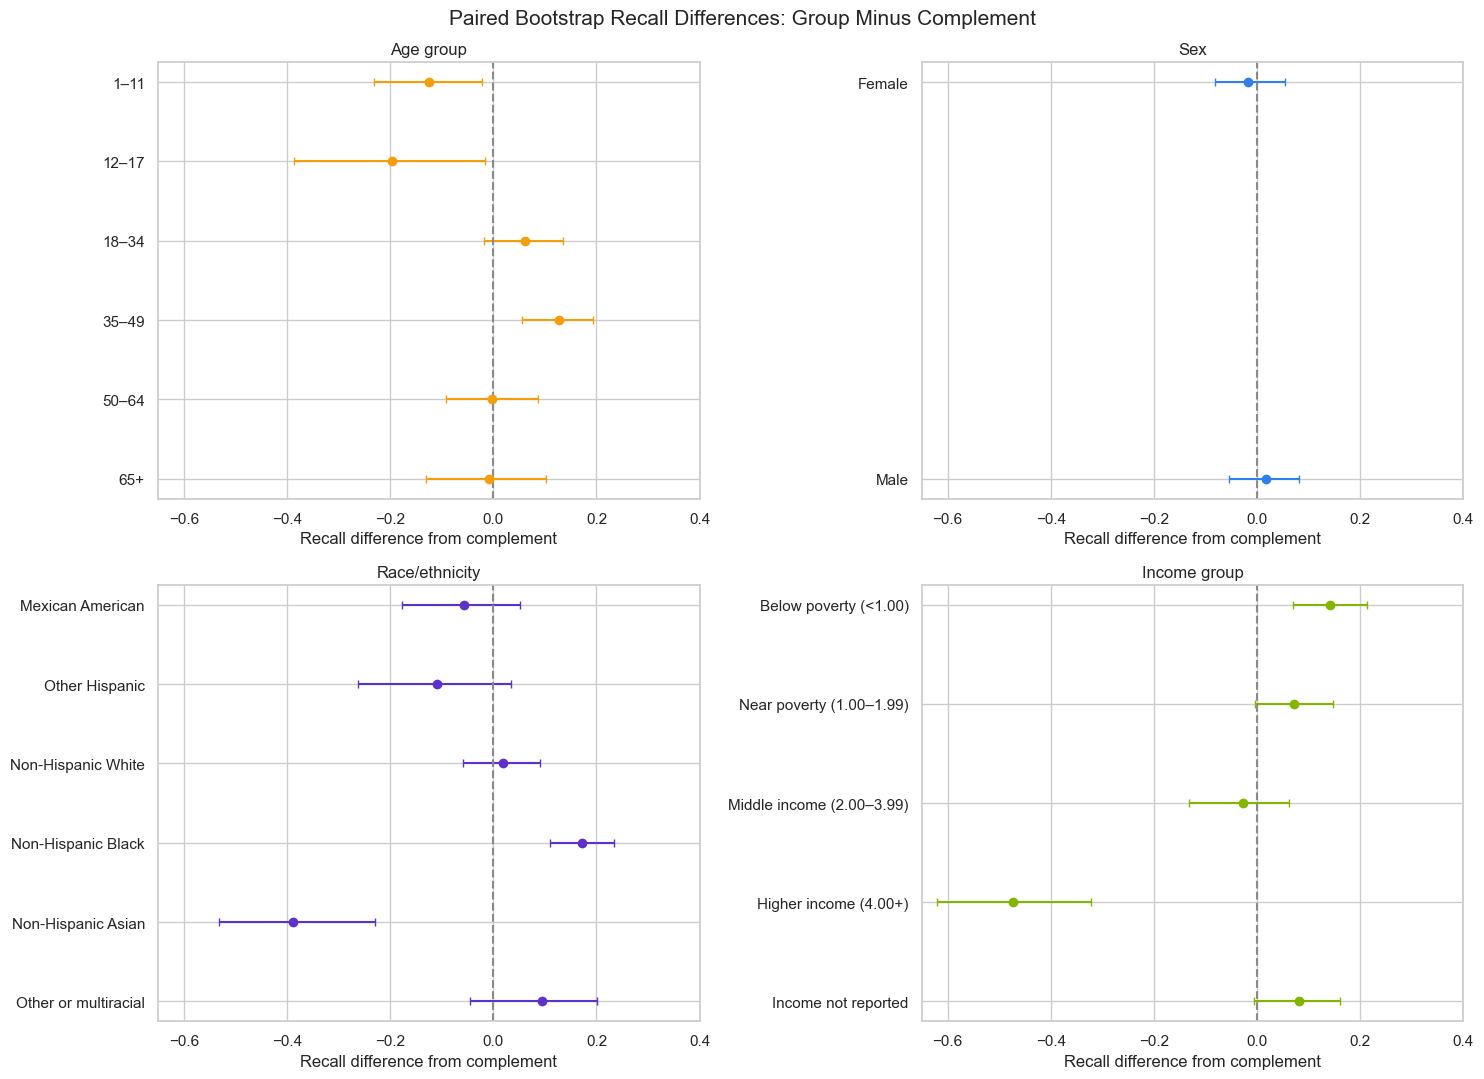

In [102]:
recall_differences = subgroup_differences.loc[
    subgroup_differences["Metric"].eq("Recall")
].copy()

figure, axes = plt.subplots(2, 2, figsize=(15, 11))
for axis, (dimension, ordered_groups) in zip(
    axes.flat,
    group_order.items(),
):
    panel = (
        recall_differences.loc[
            recall_differences["Dimension"].eq(dimension)
        ]
        .set_index("Group")
        .loc[ordered_groups]
        .reset_index()
    )
    y_positions = np.arange(len(panel))
    estimate = panel["Difference from complement"]

    axis.errorbar(
        estimate,
        y_positions,
        xerr=np.vstack(
            [
                estimate - panel["Lower 95%"],
                panel["Upper 95%"] - estimate,
            ]
        ),
        fmt="o",
        color=DIMENSION_COLORS[dimension],
        ecolor=DIMENSION_COLORS[dimension],
        capsize=3,
    )
    axis.axvline(0, color=GRAY, linestyle="--", linewidth=1.5)
    axis.set_yticks(y_positions)
    axis.set_yticklabels(panel["Group"])
    axis.invert_yaxis()
    axis.set_xlim(-0.65, 0.40)
    axis.set_xlabel("Recall difference from complement")
    axis.set_title(dimension)

figure.suptitle(
    "Paired Bootstrap Recall Differences: Group Minus Complement",
    fontsize=15,
)
plt.tight_layout()
plt.show()


In [103]:
notable_recall_differences = recall_differences.loc[
    recall_differences["Interval excludes zero"]
].sort_values("Difference from complement")
roc_differences = subgroup_differences.loc[
    subgroup_differences["Metric"].eq("ROC-AUC")
]
notable_roc_differences = roc_differences.loc[
    roc_differences["Interval excludes zero"]
].sort_values("Difference from complement")


def format_difference_rows(frame):
    if frame.empty:
        return "none"
    return "; ".join(
        f"{row['Group']}: {row['Difference from complement']:+.3f} "
        f"({row['Lower 95%']:+.3f} to {row['Upper 95%']:+.3f})"
        for _, row in frame.iterrows()
    )


recall_sentence = format_difference_rows(notable_recall_differences)
roc_sentence = format_difference_rows(notable_roc_differences)
expected_false_signals = len(subgroup_point_results) * 0.05

display(
    Markdown(
        "The recall differences whose paired intervals exclude zero are: "
        f"**{recall_sentence}**. The ROC-AUC differences whose intervals "
        f"exclude zero are: **{roc_sentence}**. Recall differences describe "
        "the frozen operating point; ROC-AUC differences describe ranking. "
        f"Across {len(subgroup_point_results)} comparisons, a complete "
        f"null would produce about {expected_false_signals:.2f} such "
        "intervals per metric by chance on average. Finding "
        f"{len(notable_recall_differences)} for recall and "
        f"{len(notable_roc_differences)} for ROC-AUC—several with "
        "large differences—is more than one isolated chance signal, "
        "but overlapping groups make that benchmark approximate. "
        "The results remain exploratory rather than formal "
        "multiplicity-corrected tests."
    )
)


The recall differences whose paired intervals exclude zero are: **Higher income (4.00+): -0.473 (-0.620 to -0.323); Non-Hispanic Asian: -0.388 (-0.532 to -0.230); 12–17: -0.197 (-0.387 to -0.017); 1–11: -0.125 (-0.231 to -0.022); 35–49: +0.127 (+0.055 to +0.193); Below poverty (<1.00): +0.141 (+0.069 to +0.213); Non-Hispanic Black: +0.172 (+0.111 to +0.234)**. The ROC-AUC differences whose intervals exclude zero are: **Non-Hispanic Asian: -0.160 (-0.247 to -0.066); Other Hispanic: -0.095 (-0.187 to -0.010); Non-Hispanic White: +0.111 (+0.065 to +0.157)**. Recall differences describe the frozen operating point; ROC-AUC differences describe ranking. Across 19 comparisons, a complete null would produce about 0.95 such intervals per metric by chance on average. Finding 7 for recall and 3 for ROC-AUC—several with large differences—is more than one isolated chance signal, but overlapping groups make that benchmark approximate. The results remain exploratory rather than formal multiplicity-corrected tests.

## Why Subgroup-Specific Thresholds Are Not Added Here

The training-only sensitivity above demonstrates that a lower cutoff can increase recall in several groups, but that does not automatically make it a valid deployment policy.

1. **Changing a threshold changes decisions, not ranking.** It can only gain recall by referring more participants.
2. **The dimensions overlap.** One participant belongs to an age, sex, race/ethnicity, and income group, so four separate cutoffs can conflict.
3. **Income is already a predictor.** Applying another income-specific cutoff would use the same information twice and could treat two people with the same predicted risk differently because of self-reported income.
4. **Race-specific thresholds require especially strong scrutiny.** They risk turning social categories into different clinical rules without proving a biological or clinical justification.
5. **The test set must remain an evaluation set.** The matched-share analysis diagnoses the mechanism but cannot select a deployable cutoff.

A legitimate future threshold change would need to be prespecified from development data, justified by clinical benefits and harms, externally or prospectively validated, reviewed for equity and legality, and monitored after deployment. Subgroup decision curves could help compare missed cavities with referral burden in that future study. Notebook 7 therefore reports the sensitivity analysis but leaves the finalized 0.130 threshold unchanged.


## Saving the Subgroup Analysis Artifacts


In [104]:
SUBGROUP_RESULTS_PATH = TABLE_FOLDER / "model_subgroup_performance.csv"
SUBGROUP_INTERVALS_PATH = (
    TABLE_FOLDER / "model_subgroup_bootstrap_intervals.csv"
)
SUBGROUP_DIFFERENCES_PATH = (
    TABLE_FOLDER / "model_subgroup_differences.csv"
)
SUBGROUP_ASSIGNMENTS_PATH = (
    TABLE_FOLDER / "model_subgroup_assignments.csv"
)
OPERATING_DIAGNOSTICS_PATH = (
    TABLE_FOLDER / "model_subgroup_operating_point_diagnostics.csv"
)
CALIBRATION_SLOPES_PATH = (
    TABLE_FOLDER / "model_subgroup_calibration_slopes.csv"
)
SELF_RATING_RACE_PATH = (
    TABLE_FOLDER / "model_self_rating_by_race.csv"
)
SUBGROUP_METADATA_PATH = MODEL_FOLDER / "model_subgroup_metadata.json"

subgroup_point_results.to_csv(SUBGROUP_RESULTS_PATH, index=False)
subgroup_intervals.to_csv(SUBGROUP_INTERVALS_PATH, index=False)
subgroup_differences.to_csv(SUBGROUP_DIFFERENCES_PATH, index=False)
analysis_data.to_csv(SUBGROUP_ASSIGNMENTS_PATH, index=False)
operating_point_diagnostics.to_csv(
    OPERATING_DIAGNOSTICS_PATH,
    index=False,
)
subgroup_calibration_slopes.to_csv(
    CALIBRATION_SLOPES_PATH,
    index=False,
)
self_rating_by_race.to_csv(SELF_RATING_RACE_PATH, index=False)

subgroup_metadata = {
    "primary_model": primary_model_name,
    "primary_model_sha256": current_model_hash,
    "primary_threshold": primary_threshold,
    "training_file_sha256": current_training_hash,
    "test_file_sha256": current_test_hash,
    "out_of_fold_predictions_sha256": hashlib.sha256(
        OOF_PREDICTIONS_PATH.read_bytes()
    ).hexdigest(),
    "test_rows": len(analysis_data),
    "subgroup_dimensions": {
        dimension: groups
        for dimension, groups in group_order.items()
    },
    "income_not_reported_handling": (
        "separate data-availability group; never assigned to an "
        "imputed income band"
    ),
    "intersectional_groups_analyzed": False,
    "models_retrained": False,
    "finalized_threshold_changed": False,
    "bootstrap": {
        "method": "ordinary participant-level percentile bootstrap",
        "resamples": N_BOOTSTRAPS,
        "confidence_level": 0.95,
        "random_state": RANDOM_STATE,
        "model_retrained": False,
        "same_indices_across_subgroups": True,
        "paired_difference_reference": (
            "everyone outside the subgroup within the same dimension; "
            "reported-income contrasts exclude income not reported"
        ),
        "subgroup_counts_fixed": False,
        "survey_design_incorporated": False,
    },
    "operating_point_sensitivity": {
        "target_recall": TARGET_RECALL,
        "development_probabilities": OOF_PREDICTIONS_PATH.name,
        "selection_rule": (
            "highest subgroup threshold whose Wilson 95% recall lower "
            "bound reaches the target"
        ),
        "matched_flag_share": overall_flag_share,
        "used_to_change_finalized_threshold": False,
        "deployment_status": (
            "diagnostic only; requires external validation and clinical, "
            "ethical, legal, and operational review"
        ),
    },
    "pr_auc_skill_definition": (
        "(PR-AUC - subgroup prevalence) / "
        "(1 - subgroup prevalence)"
    ),
    "observed_income_complements_exclude_unreported": True,
    "calibration_slope_minimum_cases": (
        MIN_CASES_FOR_CALIBRATION_SLOPE
    ),
    "survey_weight_scope": (
        "unweighted individual-level prediction; not national "
        "population estimation"
    ),
}

with open(SUBGROUP_METADATA_PATH, "w") as file:
    json.dump(subgroup_metadata, file, indent=2)

saved_artifacts = pd.DataFrame(
    [
        {
            "Artifact": "Subgroup point estimates",
            "Saved file": SUBGROUP_RESULTS_PATH.name,
        },
        {
            "Artifact": "Bootstrap confidence intervals",
            "Saved file": SUBGROUP_INTERVALS_PATH.name,
        },
        {
            "Artifact": "Paired group-complement differences",
            "Saved file": SUBGROUP_DIFFERENCES_PATH.name,
        },
        {
            "Artifact": "Participant subgroup assignments",
            "Saved file": SUBGROUP_ASSIGNMENTS_PATH.name,
        },
        {
            "Artifact": "Operating-point diagnostics",
            "Saved file": OPERATING_DIAGNOSTICS_PATH.name,
        },
        {
            "Artifact": "Supported-group calibration slopes",
            "Saved file": CALIBRATION_SLOPES_PATH.name,
        },
        {
            "Artifact": "Self-rating by race diagnostic",
            "Saved file": SELF_RATING_RACE_PATH.name,
        },
        {
            "Artifact": "Subgroup-analysis metadata",
            "Saved file": SUBGROUP_METADATA_PATH.name,
        },
    ]
)
saved_artifacts


,Artifact,Saved file
0,Subgroup point estimates,model_subgroup_performance.csv
1,Bootstrap confidence intervals,model_subgroup_bootstrap_intervals.csv
2,Paired group-complement differences,model_subgroup_differences.csv
3,Participant subgroup assignments,model_subgroup_assignments.csv
4,Operating-point diagnostics,model_subgroup_operating_point_diagnostics.csv
5,Supported-group calibration slopes,model_subgroup_calibration_slopes.csv
6,Self-rating by race diagnostic,model_self_rating_by_race.csv
7,Subgroup-analysis metadata,model_subgroup_metadata.json


## Conclusion


In [105]:
overall_recall = overall_metrics["Recall"]
higher_income = subgroup_point_results.loc[
    subgroup_point_results["Group"].eq("Higher income (4.00+)")
].iloc[0]
asian_group = subgroup_point_results.loc[
    subgroup_point_results["Group"].eq("Non-Hispanic Asian")
].iloc[0]
other_multiracial = subgroup_point_results.loc[
    subgroup_point_results["Group"].eq("Other or multiracial")
].iloc[0]
below_poverty = subgroup_point_results.loc[
    subgroup_point_results["Group"].eq("Below poverty (<1.00)")
].iloc[0]
black_group = subgroup_point_results.loc[
    subgroup_point_results["Group"].eq("Non-Hispanic Black")
].iloc[0]

asian_roc_difference = subgroup_differences.loc[
    subgroup_differences["Group"].eq("Non-Hispanic Asian")
    & subgroup_differences["Metric"].eq("ROC-AUC")
].iloc[0]
other_calibration_interval = subgroup_intervals.loc[
    subgroup_intervals["Group"].eq("Other or multiracial")
    & subgroup_intervals["Metric"].eq("Calibration gap")
].iloc[0]
sex_results = subgroup_point_results.loc[
    subgroup_point_results["Dimension"].eq("Sex")
]

display(
    Markdown(
        f"The finalized gradient-boosting model reaches "
        f"**{overall_recall:.3f} recall overall**, but the subgroup "
        "results separate into different kinds of findings.\n\n"
        "**Operating-point difference:** Higher-income participants have "
        f"{higher_income['Prevalence']:.1%} cavity prevalence and "
        f"ROC-AUC {higher_income['ROC-AUC']:.3f}, yet the global 0.130 "
        f"threshold produces only {higher_income['Recall']:.3f} recall "
        f"while flagging {higher_income['Share flagged']:.1%}. Matching "
        "the overall flag share raises recall to "
        f"{higher_income_diagnostic['Test recall at matched share']:.3f}. "
        "The threshold is therefore a major part of this gap, although "
        "lowering it would sharply increase referrals.\n\n"
        "**Ranking difference:** Non-Hispanic Asian participants have "
        f"ROC-AUC **{asian_group['ROC-AUC']:.3f}**. More importantly, "
        "their paired ROC-AUC difference from everyone outside that "
        "race/ethnicity group is "
        f"**{asian_roc_difference['Difference from complement']:+.3f}** "
        f"(95% bootstrap interval "
        f"{asian_roc_difference['Lower 95%']:+.3f} to "
        f"{asian_roc_difference['Upper 95%']:+.3f}). Moving the threshold "
        "can increase sensitivity but cannot fix weaker ranking, making "
        "this the clearest discrimination-validation priority.\n\n"
        "**Calibration difference:** Other or multiracial participants "
        f"have an average calibration gap of "
        f"**{other_multiracial['Calibration gap']:+.3f}** "
        f"(95% bootstrap interval "
        f"{other_calibration_interval['Lower 95%']:+.3f} to "
        f"{other_calibration_interval['Upper 95%']:+.3f}). This group "
        f"contains only {int(other_multiracial['Cavity cases'])} cavity "
        "cases, so the result is a separate calibration-validation "
        "priority rather than evidence that it has the same problem as "
        "the non-Hispanic Asian group.\n\n"
        "The operational burden is also uneven: the frozen threshold "
        f"flags **{below_poverty['Share flagged']:.1%}** of below-poverty "
        f"participants and **{black_group['Share flagged']:.1%}** of "
        "non-Hispanic Black participants. The flag rate by sex is more "
        f"similar, ranging from "
        f"{sex_results['Share flagged'].min():.1%} to "
        f"{sex_results['Share flagged'].max():.1%}, close to the "
        f"{overall_flag_share:.1%} flagged overall.\n\n"
        "These results do not prove a cause or establish clinical "
        "fairness. They show where ranking, calibration, threshold policy, "
        "and referral capacity need external or prospective validation. "
        "The primary model and finalized 0.130 threshold remain unchanged."
    )
)


The finalized gradient-boosting model reaches **0.818 recall overall**, but the subgroup results separate into different kinds of findings.

**Operating-point difference:** Higher-income participants have 7.8% cavity prevalence and ROC-AUC 0.732, yet the global 0.130 threshold produces only 0.381 recall while flagging 17.7%. Matching the overall flag share raises recall to 0.833. The threshold is therefore a major part of this gap, although lowering it would sharply increase referrals.

**Ranking difference:** Non-Hispanic Asian participants have ROC-AUC **0.631**. More importantly, their paired ROC-AUC difference from everyone outside that race/ethnicity group is **-0.160** (95% bootstrap interval -0.247 to -0.066). Moving the threshold can increase sensitivity but cannot fix weaker ranking, making this the clearest discrimination-validation priority.

**Calibration difference:** Other or multiracial participants have an average calibration gap of **+0.068** (95% bootstrap interval +0.017 to +0.116). This group contains only 22 cavity cases, so the result is a separate calibration-validation priority rather than evidence that it has the same problem as the non-Hispanic Asian group.

The operational burden is also uneven: the frozen threshold flags **73.4%** of below-poverty participants and **70.9%** of non-Hispanic Black participants. The flag rate by sex is more similar, ranging from 47.7% to 55.2%, close to the 51.4% flagged overall.

These results do not prove a cause or establish clinical fairness. They show where ranking, calibration, threshold policy, and referral capacity need external or prospective validation. The primary model and finalized 0.130 threshold remain unchanged.